---
### NBA Oyuncu Performans Analizi (2013-2014 Sezonu)                          
### Erhan İlke Alataş
#### Giriş

Bu çalışma, **2013-2014 NBA sezonunda** en az 40 maça çıkmış basketbolcuların performanslarını değerlendiren kapsamlı bir veri seti üzerinden yürütülmektedir. Analizimiz, sezonun En Değerli Oyuncusu (EDO) olarak seçilen **Kevin Durant** ve diğer seçkin oyuncuların performans göstergelerini derinlemesine inceler. Bu göstergeler, oyuncuların sezon boyunca sergiledikleri performansın boyutlarını ve kalitesini anlamamıza yardımcı olacak detaylı değişkenlerle zenginleştirilmiştir.

#### Bağımlı Değişken

- **PER (Oyuncu Verimlilik Derecesi):** Oyuncunun dakika başına üretkenliğini ölçen, lig ortalaması 15 olacak şekilde standardize edilmiş bir göstergedir. PER, oyuncunun sahadaki etkinliğinin ve katkısının önemli bir ölçütüdür.

#### Açıklayıcı Değişkenler

Aşağıdaki değişkenler, oyuncuların performansını detaylı bir şekilde analiz etmemize olanak tanır:

- **Player:** Basketbolcu isimleri.
- **Age:** 1 Şubat 2014 itibarıyla oyuncunun yaşı.
- **Games:** Bir oyuncunun oynadığı maç sayısı.
- **Minutes:** Bir oyuncunun sahada geçirdiği süre.
- **TS% (Isabetli Atış Yüzdesi):** 2 sayılık, 3 sayılık ve serbest atışları içeren, atış verimliliğini gösteren bir ölçüt.
- **ORB / DRB / TRB:** Sırasıyla ofansif, defansif ve toplam ribaund yüzdesi.
- **AST:** Asist yüzdesi.
- **STL:** Top çalma yüzdesi.
- **BLK:** Blok yüzdesi.
- **TOV:** Top kaybı yüzdesi.
- **USG%:** Topa sahip olma yüzdesi.
- **ORtg / DRtg:** Sırasıyla 100 ofansif / defansif atakta atılan sayı yüzdesi.
- **OWS / DWS:** Atak ve defansta kazandırılan galibiyet sayısına katkı.
- **WS:** Kazanma yüzdesi.

####  Araştırmanın Amacı

Bu analizle, **NBA'de 2013-2014 sezonunda** sahne alan basketbolcuların detaylı performans göstergeleri üzerinden üstün başarı gösteren oyuncuları belirlemeyi hedefliyoruz. Oyuncuların sahadaki etkilerinin objektif verilerle değerlendirilmesi ve bu performansların takımlarının genel başarısına olan katkılarının derinlemesine analiz edilmesi ana amacımızdır.

---

---
### 📊 Veri Seti
---

- https://www.statcrunch.com/app/index.html?dataid=1096769&groupid=958

---
### 📚 Gerekli Kütüphanelerin Yüklenmesi
---

In [1]:
# Veri Manipülasyonu
import numpy as np
import pandas as pd

# Görselleştirme Kütüphaneleri
import seaborn as sns
import matplotlib.pyplot as plt

# Önişleme ve Model Seçimi
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score, cross_validate, validation_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, scale

# Modeller
from sklearn.linear_model import ElasticNetCV
from sklearn import model_selection
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA

# Model Değerlendirme Metrikleri
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# İstatistiksel Testler
from scipy.stats import levene
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


---
### 📊 Veri Setinin İçe Aktarılması
---

In [2]:
data = pd.read_excel("NBA.xlsx")

---
### 🔍 Gelişmiş Fonksiyonel Keşifçi Veri Analizi 
Veri setimizin derinlemesine analizine giriş yapıyoruz, önemli öngörüler elde etmeyi hedefliyoruz.
#### 1. Genel Resim
Veri setimizin genel yapısı ve temel istatistiklerine genel bir bakış.
#### 2. Kategorik Değişken Analizi 
Kategorik değişkenlerin dağılımı ve hedef değişkenle ilişkileri üzerine odaklanma.
#### 3. Sayısal Değişken Analizi 
Sayısal değişkenlerin temel istatistikleri ve veri setindeki rollerinin incelenmesi.
#### 4. Hedef Değişken Analizi 
Hedef değişkenin incelemesi, dağılımı ve diğer değişkenlerle ilişkisi.
#### 5. Korelasyon Analizi 
Değişkenler arası ilişkilerin ve hedef değişken üzerindeki etkilerinin keşfi.

---

---
### 1. Genel Resim
---

In [3]:
def check_df(dataframe, head=5):
    print("\n" + "#" * 50 + " Shape " + "#" * 50)
    print(f"📏 Rows: {dataframe.shape[0]}, Columns: {dataframe.shape[1]}")

    print("\n" + "#" * 50 + " Types " + "#" * 50)
    print("🔤" + "\n" + str(dataframe.dtypes))

    print("\n" + "#" * 50 + " Head " + "#" * 50)
    print("🔝" + "\n" + str(dataframe.head(head)))

    print("\n" + "#" * 50 + " Tail " + "#" * 50)
    print("🔚" + "\n" + str(dataframe.tail(head)))

    print("\n" + "#" * 50 + " Missing Values " + "#" * 50)
    missing_values = dataframe.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if len(missing_values) > 0:
        print("❗" + "\n" + str(missing_values))
    else:
        print("✅ No missing values.")

    print("\n" + "#" *50 + " Quantiles " + "#" * 50)
    print("📊" + "\n" + str(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1], numeric_only=True).T))
    
check_df(data)


################################################## Shape ##################################################
📏 Rows: 342, Columns: 21

################################################## Types ##################################################
🔤
Player       object
Position     object
Age           int64
Team         object
Games         int64
Minutes       int64
PER         float64
TS          float64
ORB         float64
DRB         float64
TRB         float64
AST         float64
STL         float64
BLK         float64
TOV         float64
USG         float64
ORtg          int64
DRtg          int64
OWS         float64
DWS         float64
WS          float64
dtype: object

################################################## Head ##################################################
🔝
             Player Position  Age Team  Games  Minutes   PER     TS   ORB  \
0      Kevin Durant       SF   25  OKC     81     3122  29.8  0.635   2.2   
1      LeBron James       PF   29  MIA     77     2902  2

In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """


    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]


    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(data)

Observations: 342
Variables: 21
cat_cols: 1
num_cols: 18
cat_but_car: 2
num_but_cat: 0


---
### 2. Kategorik Değişken Analizi
---

          Position      Ratio
Position                     
PF              73  21.345029
SF              71  20.760234
SG              70  20.467836
PG              63  18.421053
C               61  17.836257
SG-PG            1   0.292398
SF-PF            1   0.292398
PF-SF            1   0.292398
SG-SF            1   0.292398
----------------------------------------------------------------------------------------------------


/var/folders/6w/4105lrq51jd2q932qk9qh73m0000gn/T/ipykernel_39354/1500807163.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=dataframe[col_name], data=dataframe, palette="viridis")


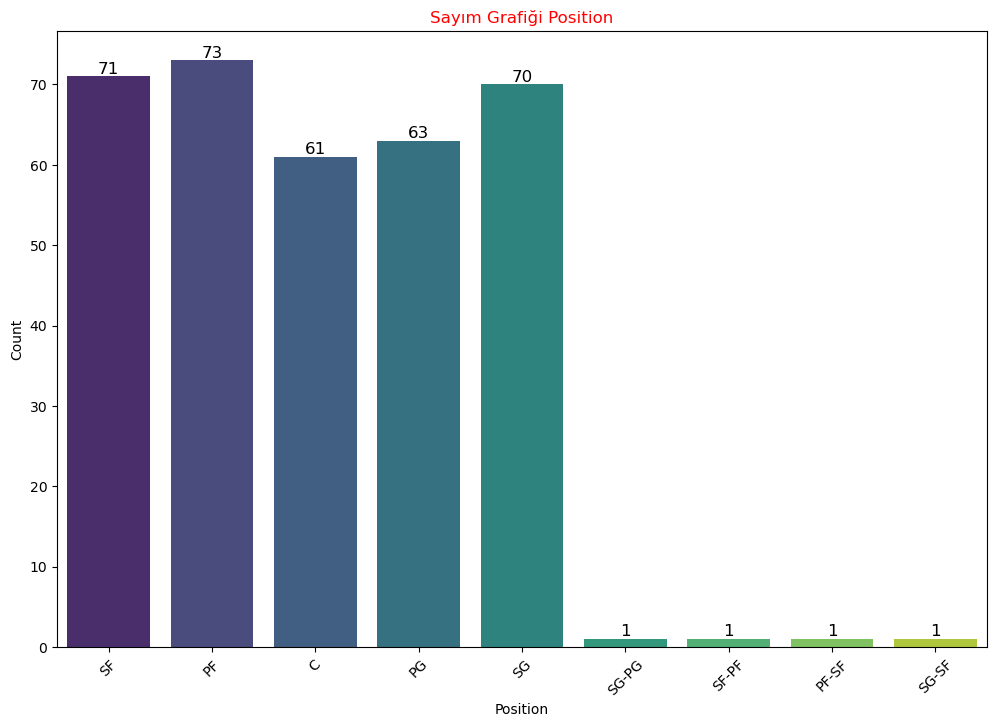

In [5]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    
    print("-" * 100)

    if plot:
        plt.figure(figsize=(12, 8))
        ax = sns.countplot(x=dataframe[col_name], data=dataframe, palette="viridis")
        plt.title(f'Sayım Grafiği {col_name}', color='red')  
        plt.xlabel(f'{col_name}')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        for p in ax.patches: 
            ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), 
                    fontsize=12, ha='center', va='bottom')
        

for col in cat_cols:
    cat_summary(data, col, plot=True)

---
### 3. Sayısal Değişken Analizi
---

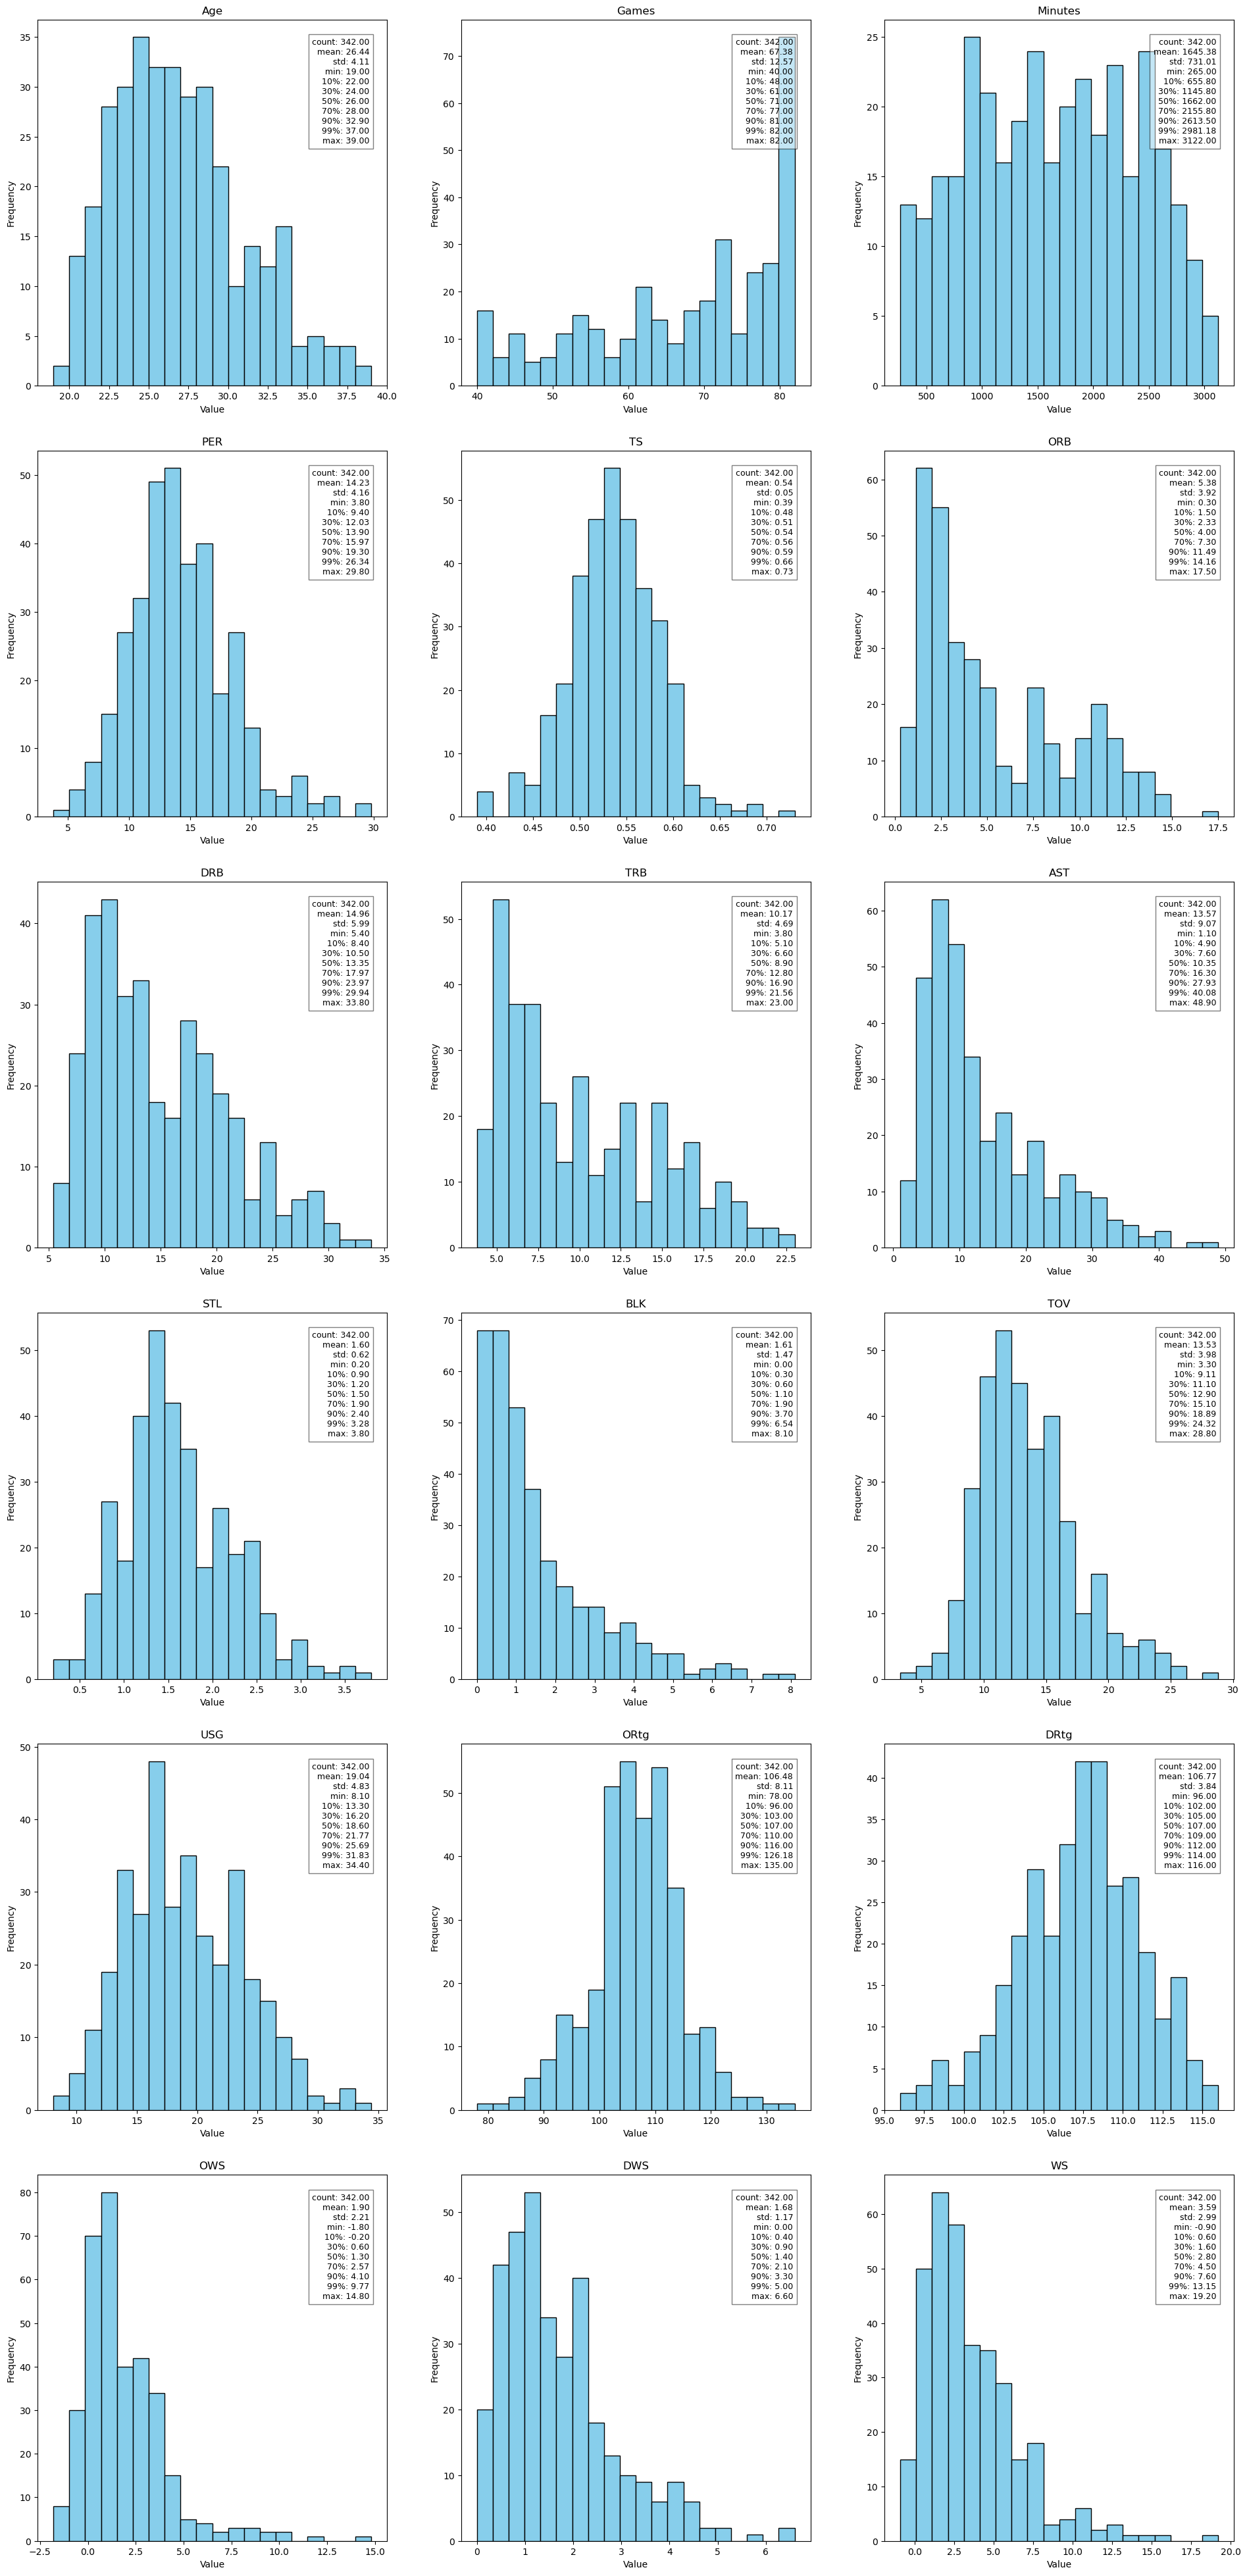

In [6]:
numerical_cols=[col for col in data.columns if data[col].dtypes in ["int64","float64"]]
def num_summary(dataframe, numerical_cols, plot=False):
    quantiles = [0.10, 0.30, 0.50, 0.70, 0.90, 0.99]
    
    
    if plot:
        fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 40))
        fig.tight_layout(pad=5.0)
        
        for col, ax in zip(numerical_cols, axes.flatten()):
            stats = dataframe[col].describe(quantiles)
            ax.hist(dataframe[col].dropna(), bins=20, color='skyblue', edgecolor='black')
            ax.set_title(col)
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            stats_text = '\n'.join([f'{idx}: {value:.2f}' for idx, value in stats.items()])
            ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top', 
                    horizontalalignment='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
        plt.show()
    else:
        for col in numerical_cols:
            stats = dataframe[col].describe(quantiles)
            print(stats)


num_summary(data, numerical_cols, plot=True)

---
###  4. Hedef Değişken Analizi
---

Player Kategorisine Göre PER Ortalamaları:
                  Player  TARGET_MEAN
            Aaron Brooks         12.5
            Al Jefferson         22.7
         Al-Farouq Aminu         13.2
           Alan Anderson          9.5
              Alec Burks         15.8
                Alex Len          7.3
            Alexey Shved         10.2
           Alexis Ajinca         14.6
              Alonzo Gee          8.6
       Amar'e Stoudemire         18.8
            Amir Johnson         15.4
        Anderson Varejao         17.0
          Andray Blatche         18.8
          Andre Drummond         22.6
          Andre Iguodala         13.7
            Andre Miller         13.9
          Andre Roberson          9.0
         Andrea Bargnani         14.5
        Andrei Kirilenko         12.4
            Andrew Bogut         17.0
        Andrew Nicholson          9.9
         Anthony Bennett          6.9
           Anthony Davis         26.5
          Anthony Morrow         13.9
       

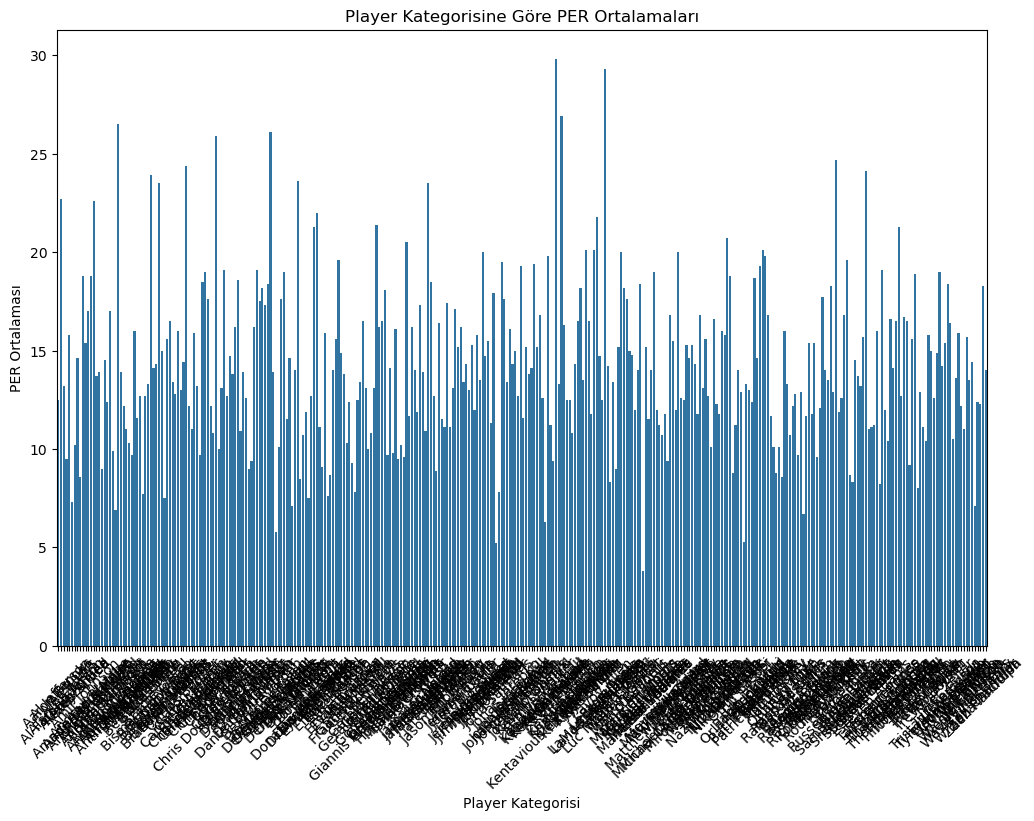

Position Kategorisine Göre PER Ortalamaları:
Position  TARGET_MEAN
       C        15.79
      PF        15.36
   PF-SF         8.30
      PG        14.51
      SF        12.81
   SF-PF        11.50
      SG        13.10
   SG-PG        14.10
   SG-SF         7.80


----------------------------------------------------------------------------------------------------


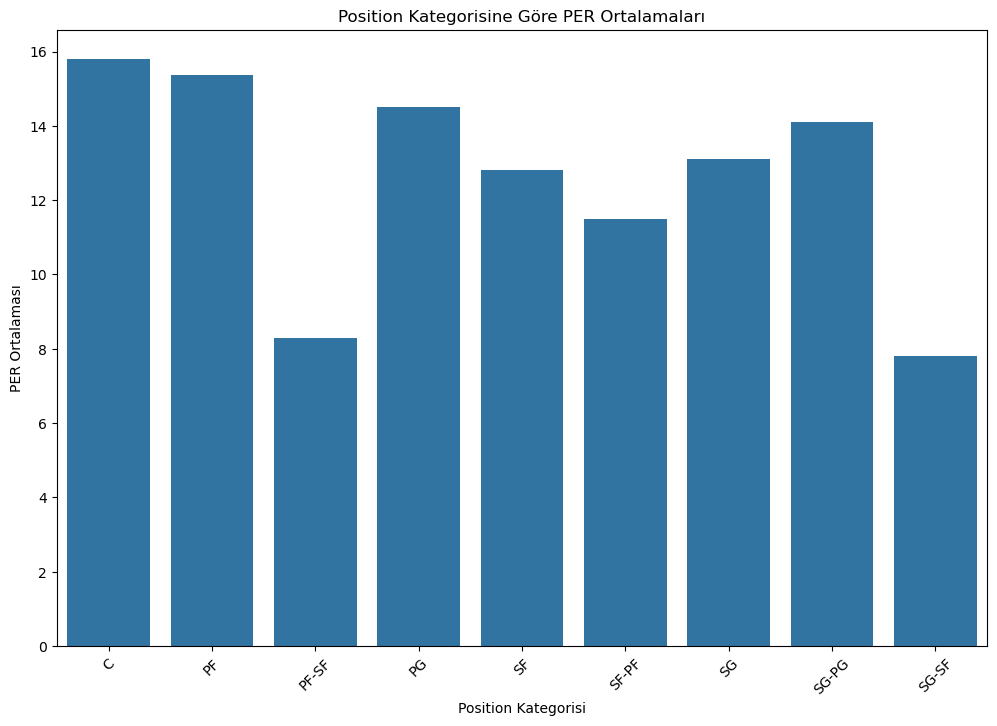

Team Kategorisine Göre PER Ortalamaları:
Team  TARGET_MEAN
 ATL        13.85
 BOS        13.36
 BRK        15.17
 CHA        14.22
 CHI        13.18
 CLE        13.51
 DAL        15.82
 DEN        13.95
 DET        14.82
 GSW        15.69
 HOU        15.34
 IND        14.01
 LAC        14.81
 LAL        14.49
 MEM        15.78
 MIA        15.55
 MIL        13.23
 MIN        14.75
 NOP        14.58
 NYK        14.96
 OKC        14.32
 ORL        13.56
 PHI        11.66
 PHO        14.65
 POR        14.69
 SAC        14.25
 SAS        15.73
 TOR        15.33
 TOT        12.30
 UTA        13.31
 WAS        14.51


----------------------------------------------------------------------------------------------------


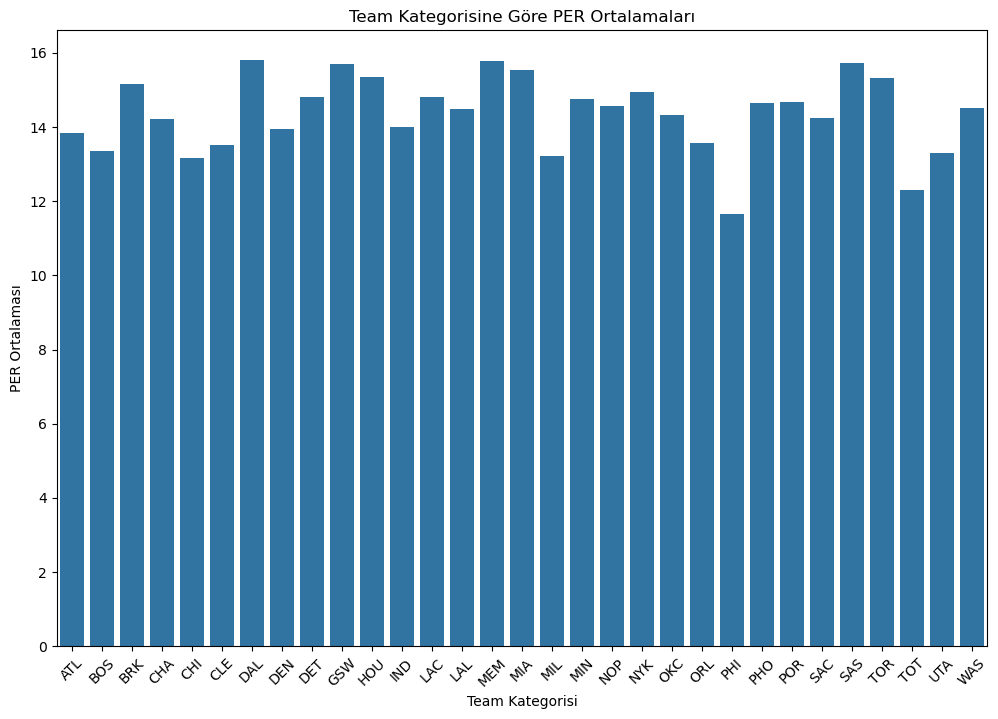

In [7]:
cat_cols=[col for col in data.columns if data[col].dtypes in ["object","category","bool"]]
def target_summary_with_cat(dataframe, target, categorical_col):
    summary_df = pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}).reset_index()
    summary_df = summary_df.round(2)  
    summary_df[categorical_col] = summary_df[categorical_col].astype(str)  

    print(f"{categorical_col} Kategorisine Göre {target} Ortalamaları:")
    print(summary_df.to_string(index=False), end="\n\n\n")
    print("-" * 100)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=categorical_col, y="TARGET_MEAN", data=summary_df)
    plt.xticks(rotation=45)
    plt.title(f"{categorical_col} Kategorisine Göre {target} Ortalamaları") 
    plt.xlabel(f"{categorical_col} Kategorisi")
    plt.ylabel(f"{target} Ortalaması")
    plt.show()
    

for col in cat_cols:
    target_summary_with_cat(data, "PER", col)

---
### 5. Korelasyon Analizi
---

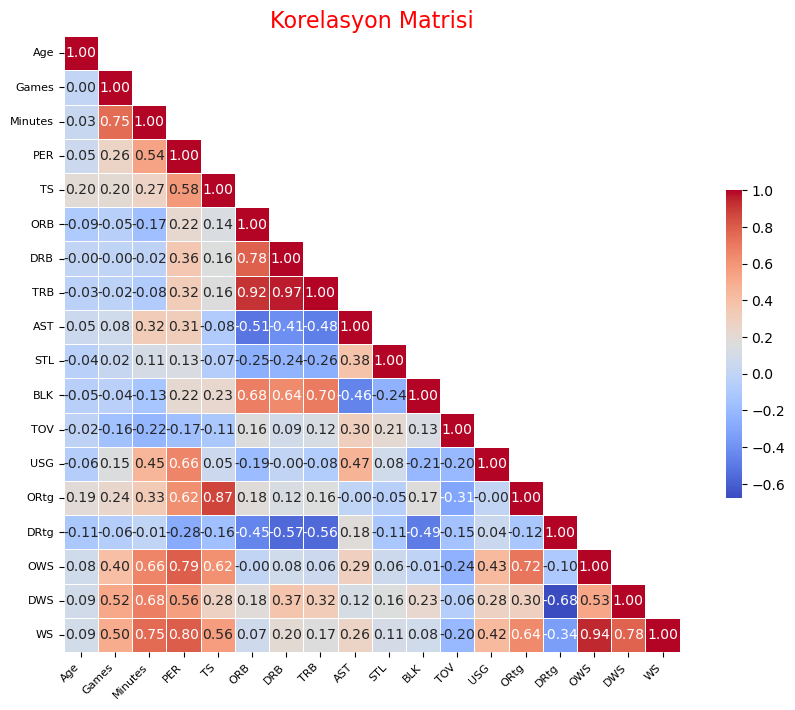

Yüksek korelasyona sahip sütun çiftleri (0.9 üzeri):
  Sütun 1 Sütun 2  Korelasyon Değeri
0     ORB     TRB           0.916649
1     DRB     TRB           0.966269
2     OWS      WS           0.942930


In [8]:

def high_correlated_cols_df(dataframe, corr_th=0.90, figsize=(12, 8)):
    """
    Veri çerçevesinin korelasyon matrisini çizer ve korelasyon değerlerini ısı haritası üzerinde sayısal olarak gösterir.
    Aynı zamanda, belirlenen korelasyon eşiğini aşan sütun çiftlerini ve bu çiftlerin korelasyon değerlerini içeren bir DataFrame döndürür.

    Parameters:
    dataframe (pd.DataFrame): Analiz edilecek veri çerçevesi.
    corr_th (float): Yüksek korelasyon eşiği (varsayılan 0.90).
    figsize (tuple): Figür boyutu (varsayılan (10, 8)).

    Returns:
    pd.DataFrame: Eşiği aşan korelasyonlara sahip sütun çiftleri ve korelasyon değerleri.
    """
    corr = dataframe.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    upper_triangle_matrix = corr.where(mask)

    # Korelasyon eşiğini aşan değerleri içeren çiftleri bul
    high_corr_pairs = [(i, j, upper_triangle_matrix.loc[i,j]) for i in upper_triangle_matrix.columns for j in upper_triangle_matrix.columns if upper_triangle_matrix.loc[i,j] > corr_th]

    # Çizim yap
    plt.figure(figsize=figsize)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.ylim(len(corr), 0)
    plt.title("Korelasyon Matrisi", fontsize=16, color = 'red')
    plt.xticks(fontsize=8, rotation=45, ha="right")
    plt.yticks(fontsize=8)
    plt.show()

    if len(high_corr_pairs) == 0:
        print("Yüksek korelasyona sahip sütun çifti bulunamadı.")
        return pd.DataFrame()
    else:
        high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Sütun 1', 'Sütun 2', 'Korelasyon Değeri'])
        print(f"Yüksek korelasyona sahip sütun çiftleri ({corr_th} üzeri):\n{high_corr_df}")
        return high_corr_df
    
drop_list = high_correlated_cols_df(dataframe=data)

---
### Oyuncu Analizi
---

/var/folders/6w/4105lrq51jd2q932qk9qh73m0000gn/T/ipykernel_39354/3917034115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WS', y='Player', data=ws_sorted, palette='coolwarm')


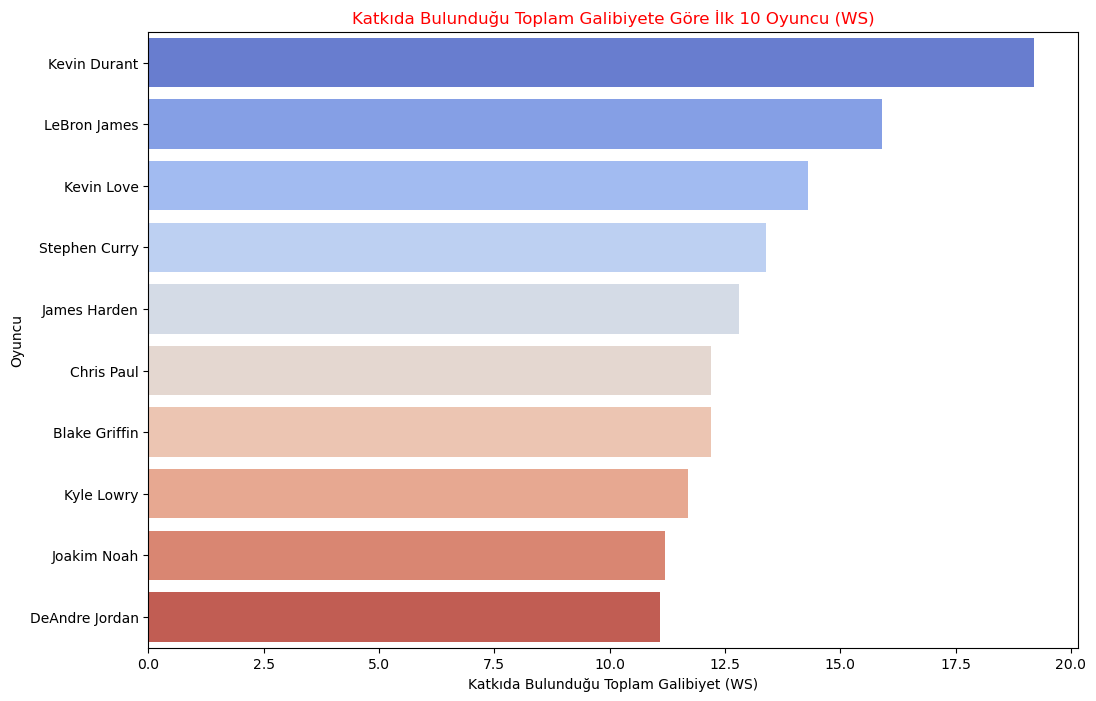

In [9]:
# Oyuncuların Toplam Kazandırdığı Maç Sayısına (WS) Göre Sıralaması
ws_sorted = data.sort_values('WS', ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='WS', y='Player', data=ws_sorted, palette='coolwarm')
plt.title('Katkıda Bulunduğu Toplam Galibiyete Göre İlk 10 Oyuncu (WS)', color = 'red')
plt.xlabel('Katkıda Bulunduğu Toplam Galibiyet (WS)')
plt.ylabel('Oyuncu')
plt.show()

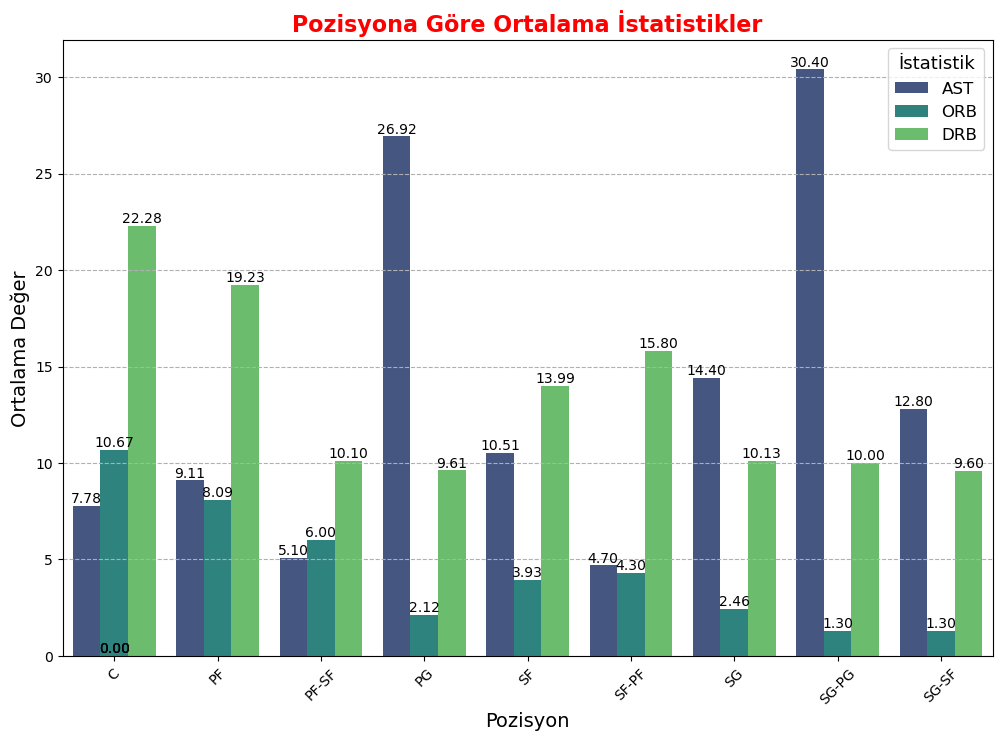

In [10]:
position_stats = data.groupby('Position').mean(numeric_only=True)
selected_stats = position_stats[['AST', 'ORB', 'DRB']]

selected_stats_long = selected_stats.reset_index().melt(id_vars='Position', var_name='Statistic', value_name='Average')
plt.figure(figsize=(12, 8))
sns.barplot(data=selected_stats_long, x='Position', y='Average', hue='Statistic', palette='viridis')
plt.title('Pozisyona Göre Ortalama İstatistikler', fontsize=16, fontweight='bold', color = 'red')
plt.ylabel('Ortalama Değer', fontsize=14)
plt.xlabel('Pozisyon', fontsize=14)
plt.legend(title='İstatistik', title_fontsize='13', fontsize='12', loc='upper right')
plt.grid(axis='y', linestyle='--')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2., p.get_height(), f'{p.get_height():.2f}', 
             ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.show()

---
### Aykırı Değer Analizi
---

In [11]:
num_cols1 = data.select_dtypes(include=['float64', 'int64']).columns

# Aykırı gözlemleri IQR yöntemiyle belirleme
Q1 = data[num_cols1].quantile(0.25)
Q3 = data[num_cols1].quantile(0.75)
IQR = Q3 - Q1

outliers_numeric = ((data[num_cols] < (Q1 - 1.5 * IQR)) | (data[num_cols] > (Q3 + 1.5 * IQR)))
outlier_summary_numeric = outliers_numeric.sum().sort_values(ascending=False)
filtered_outliers_summary = outlier_summary_numeric[outlier_summary_numeric > 0]
outlier_summary_str = "\n".join([f"{index}: {value} Aykırı Değer" for index, value in filtered_outliers_summary.items()])

print("Aykırı Değer Analizi Sonuçları:\n")
print(outlier_summary_str)

Aykırı Değer Analizi Sonuçları:

BLK: 16 Aykırı Değer
OWS: 14 Aykırı Değer
WS: 13 Aykırı Değer
TOV: 12 Aykırı Değer
PER: 11 Aykırı Değer
ORtg: 10 Aykırı Değer
DWS: 9 Aykırı Değer
AST: 9 Aykırı Değer
TS: 8 Aykırı Değer
STL: 4 Aykırı Değer
DRB: 2 Aykırı Değer
DRtg: 2 Aykırı Değer
USG: 1 Aykırı Değer
ORB: 1 Aykırı Değer
Age: 1 Aykırı Değer


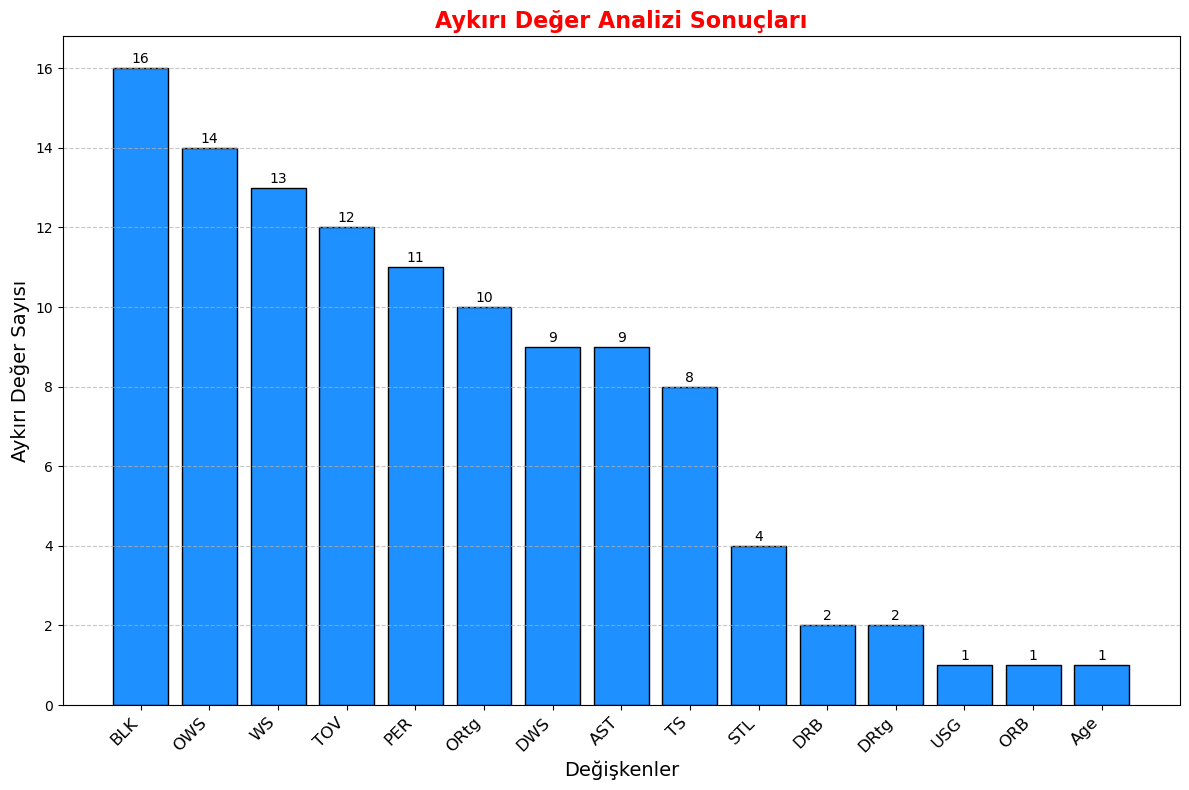

In [12]:
# Aykırı Değer Analizi Sonuçlarını Çubuk Grafiği ile Görselleştirme
plt.figure(figsize=(12, 8))
bars = plt.bar(filtered_outliers_summary.index, filtered_outliers_summary.values, color='dodgerblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + .05, yval, ha='center', va='bottom')

plt.xlabel('Değişkenler', fontsize=14)
plt.ylabel('Aykırı Değer Sayısı', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Aykırı Değer Analizi Sonuçları', fontsize=16, fontweight='bold', color='red')
plt.tight_layout()

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

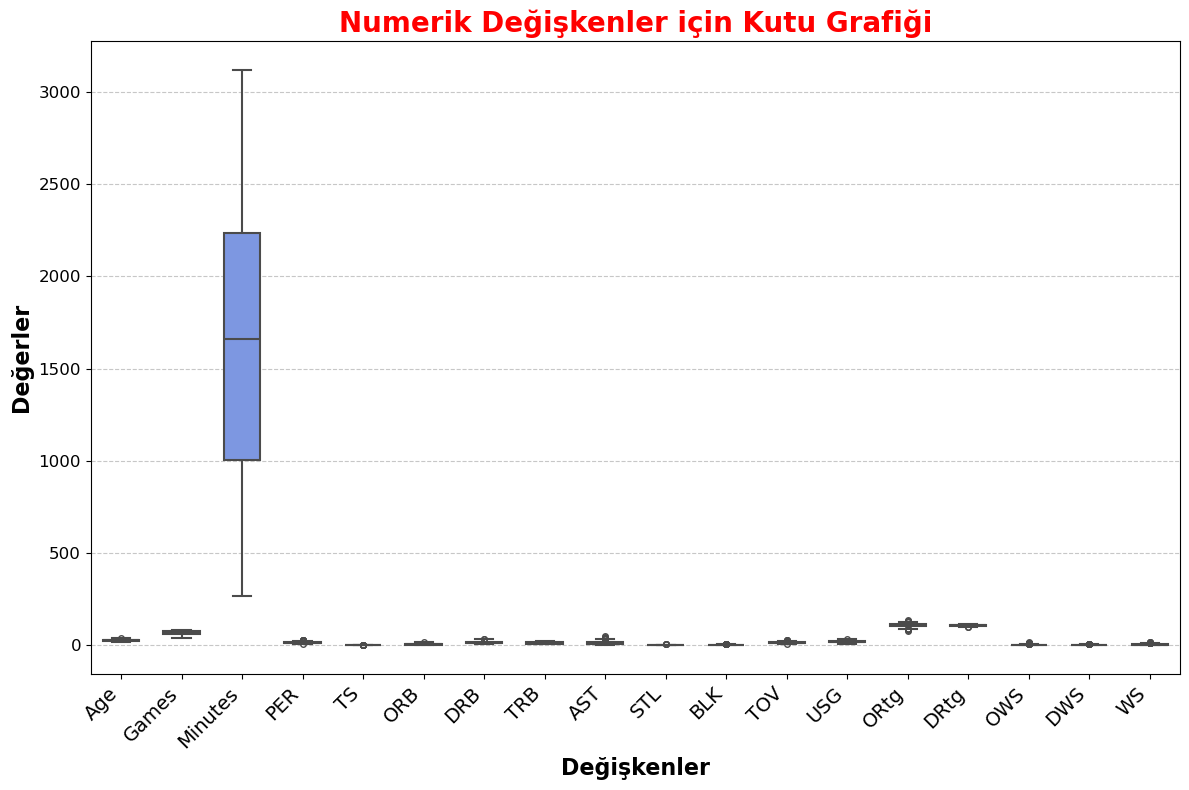

In [13]:
# Kutu Grafiği ile Aykırı Gözlem Analizi
num_cols_df = data[num_cols]
plt.figure(figsize=(12, 8))
sns.boxplot(data=num_cols_df, palette="coolwarm", width=0.6, fliersize=4, linewidth=1.5)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=12)
plt.xlabel('Değişkenler', fontsize=16, fontweight='bold')
plt.ylabel('Değerler', fontsize=16, fontweight='bold')
plt.title('Numerik Değişkenler için Kutu Grafiği', fontsize=20, fontweight='bold', color='red')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
### 🔍Çok Değişkenli Aykırı Gözlem Analizi
---

- **Local Outlier Factor (LOF)**, gözlemleri bulundukları konumda yoğunluk tabanlı olarak skorlayarak aykırı değerleri tanımlamamıza olanak sağlar.

- Bir noktanın lokal yoğunluğu, bu noktanın komşuları ile karşılaştırılarak belirlenir. Eğer bir nokta, komşularının yoğunluğundan anlamlı şekilde düşük ise, bu nokta komşularından daha seyrek bir bölgede bulunuyor demektir. Bu durumda bir komşuluk yapısı gözlemlenir.

- Bir değerin çevresi yoğun değilse, bu değer aykırı bir değer olarak değerlendirilir.

In [14]:
def detect_outliers(data, num_cols):
    """
    Veri setindeki sayısal sütunlar için aykırı değerleri tespit eder.
    Aykırı değerleri ve normal değerleri sayar, aykırı değer içeren gözlemleri döndürür.

    Parametreler:
    - data (pd.DataFrame): İşlenecek veri seti.
    - num_cols (list): Aykırı değer tespiti yapılacak sayısal sütunların isimleri.

    Döndürülen Değerler:
    - outlier_count (int): Aykırı değer sayısı.
    - normal_count (int): Normal değer sayısı.
    - outliers_df (pd.DataFrame): Aykırı değer içeren gözlemler.
    """
    # Aykırı değer tespiti
    numeric_data = data[num_cols]
    lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
    data['Outlier'] = lof.fit_predict(numeric_data)

    # Aykırı ve normal değer sayıları
    outlier_count = (data['Outlier'] == -1).sum()
    normal_count = (data['Outlier'] == 1).sum()

    # Aykırı değer içeren gözlemler
    outliers_df = data[data['Outlier'] == -1]

    return outlier_count, normal_count, outliers_df


outlier_count, normal_count, outliers_df = detect_outliers(data, num_cols)

print(f"Toplam {outlier_count} aykırı değer bulundu. ")
print(f"Veri setindeki toplam oyuncu sayısına oranı: {outlier_count / (outlier_count + normal_count):.2%}")
print("-" * 100)
print("\nAykırı Değer Olarak Belirlenen Oyuncular:")
print(outliers_df.T)


Toplam 1 aykırı değer bulundu. 
Veri setindeki toplam oyuncu sayısına oranı: 0.29%
----------------------------------------------------------------------------------------------------

Aykırı Değer Olarak Belirlenen Oyuncular:
                     0
Player    Kevin Durant
Position            SF
Age                 25
Team               OKC
Games               81
Minutes           3122
PER               29.8
TS               0.635
ORB                2.2
DRB               18.6
TRB               10.8
AST               26.7
STL                1.7
BLK                1.5
TOV               12.2
USG               33.0
ORtg               123
DRtg               104
OWS               14.8
DWS                4.4
WS                19.2
Outlier             -1


---
###  Çoklu Lineer Regresyon
---

In [15]:
# Hedef Değişkenler ve Bağımsız Değişkenler
X = data.drop(['Player', 'Position', 'Team', 'PER'], axis=1)
y = data['PER']

In [16]:
# Train ve Test Olarak Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 53)

In [17]:
# Stats paketi ile Model Kurmak
# X_train'e sabit terim ekliyoruz
X_train_const = sm.add_constant(X_train) 
model_stats = sm.OLS(y_train, X_train_const).fit()

In [18]:
# Model çıktısı
model_stats.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PER   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     605.1
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          2.65e-176
Time:                        16:15:55   Log-Likelihood:                -214.11
No. Observations:                 239   AIC:                             466.2
Df Residuals:                     220   BIC:                             532.3
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -20.5600      3.912     -5.255      0.000     -28.271     -12.850
Age            0.0166      0.011      1.515      0.131      -0.005       0.038
Games         -0.0078      0.006     -1.403      0.162      -0.019       0.003
Minutes        0.0002      0.000      1.025      0.306      -0.000       0.001
TS            16.0565      3.425      4.688      0.000       9.307      22.806
ORB            0.3140      0.200      1.569      0.118      -0.080       0.708
DRB            0.2279      0.195      1.171      0.243      -0.156       0.611
TRB           -0.2141      0.396     -0.541      0.589      -0.994       0.566
AST            0.1258      0.014      9.236      0.000       0.099       0.153
STL            1.0186      0.082     12.437      0.000       0.857       1.180
BLK            0.5260      0.041     12.829      0.000       0.445       0.607
TOV           -0.1353      0.029     -4.617      0.000      -0.193      -0.078
USG            0.4050      0.019     21.456      0.000       0.368       0.442
ORtg           0.1142      0.026      4.373      0.000       0.063       0.166
DRtg           0.0042      0.031      0.136      0.892      -0.057       0.065
OWS           -1.1444      0.855     -1.338      0.182      -2.830       0.542
DWS           -1.4818      0.847     -1.748      0.082      -3.152       0.188
WS             1.4724      0.847      1.738      0.084      -0.198       3.143
Outlier       -0.2780      0.361     -0.770      0.442      -0.990       0.434
==============================================================================
Omnibus:                        0.843   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.656   Jarque-Bera (JB):                0.549
Skew:                          -0.006   Prob(JB):                        0.760
Kurtosis:                       3.234   Cond. No.                     1.95e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.95e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- R-kare ve Düzeltilmiş R-kare değerleri `0.998`, yani modelin PER'i açıklama yeteneği çok yüksek. F-istatistiği `7378` ve ilgili p-değeri çok küçük, bu da modelin istatistiksel olarak anlamlı olduğunu gösteriyor. 

- Her bir bağımsız değişkenin katsayısı (`coef`), standart hatası (`std err`), t-istatistiği ve p-değeri bulunuyor. 

  - `Age` ve `Games` değişkenleri istatistiksel olarak anlamlı değil (p>0.05). 
  - `Minutes`, `TS` (muhtemelen True Shooting yüzdesi), `ORB` (Offensive Rebounds), `DRB` (Defensive Rebounds), `AST` (Assists), `STL` (Steals), `BLK` (Blocks), `USG` (Usage Rate), `ORtg` (Offensive Rating) ve `DRtg` (Defensive Rating) gibi değişkenler istatistiksel olarak anlamlı (p<0.05).


- Modelin diğer diagnostik ölçütleri (Omnibus, Durbin-Watson, Jarque-Bera, Skewness, Kurtosis, Condition Number) genel olarak modelin iyi uyum sağladığını ve varsayımların çoğunu karşıladığını gösteriyor.

In [19]:
# Sklearn Kütüphanesi ile Model Kurmak
model_sklearn = LinearRegression().fit(X_train, y_train)

In [20]:
# Parametre Tahminleri ve Çıktılar
intercept = model_sklearn.intercept_
coefficients = model_sklearn.coef_
feature_names = [
    'Age', 'Games', 'Minutes', 'TS', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV', 
    'USG', 'ORtg', 'DRtg', 'OWS', 'DWS', 'WS'
]
print(f"Modelin Kesme Noktası (Intercept): {intercept:.4f}\n")
print("Model Katsayıları;")
for feature_name, coef in zip(feature_names, coefficients):
    print(f"{feature_name}: {coef:.4f}")

Modelin Kesme Noktası (Intercept): -20.5600

Model Katsayıları;
Age: 0.0166
Games: -0.0078
Minutes: 0.0002
TS: 16.0565
ORB: 0.3140
DRB: 0.2279
AST: -0.2141
STL: 0.1258
BLK: 1.0186
TOV: 0.5260
USG: -0.1353
ORtg: 0.4050
DRtg: 0.1142
OWS: 0.0042
DWS: -1.1444
WS: -1.4818


In [21]:
# İn-Sample R^2 ve MSE
yhat = model_sklearn.predict(X_train)
r2_in_linear = r2_score(y_train, yhat)
mse_in_linear = mean_squared_error(y_train, yhat)
print(f"Linear Regresyon İle Kurulan Model için R^2 Skoru: {r2_in_linear:.4f}")  
print(f"Linear Regresyon İle Kurulan Model için Ortalama Kare Hata (MSE): {mse_in_linear:.4f}") 

Linear Regresyon İle Kurulan Model için R^2 Skoru: 0.9802
Linear Regresyon İle Kurulan Model için Ortalama Kare Hata (MSE): 0.3513


In [22]:
# Out-of-prediction
y_tahmin = model_sklearn.predict(X_test)
r2_out_linear = r2_score(y_test, y_tahmin)
mse_out_linear = mean_squared_error(y_test, y_tahmin)
print(f"Linear Regresyon İle Kurulan Model için R^2 Skoru: {r2_out_linear:.4f}")  
print(f"Linear Regresyon İle Kurulan Model için Ortalama Kare Hata (MSE): {mse_out_linear:.4f}")  

Linear Regresyon İle Kurulan Model için R^2 Skoru: 0.9720
Linear Regresyon İle Kurulan Model için Ortalama Kare Hata (MSE): 0.4379


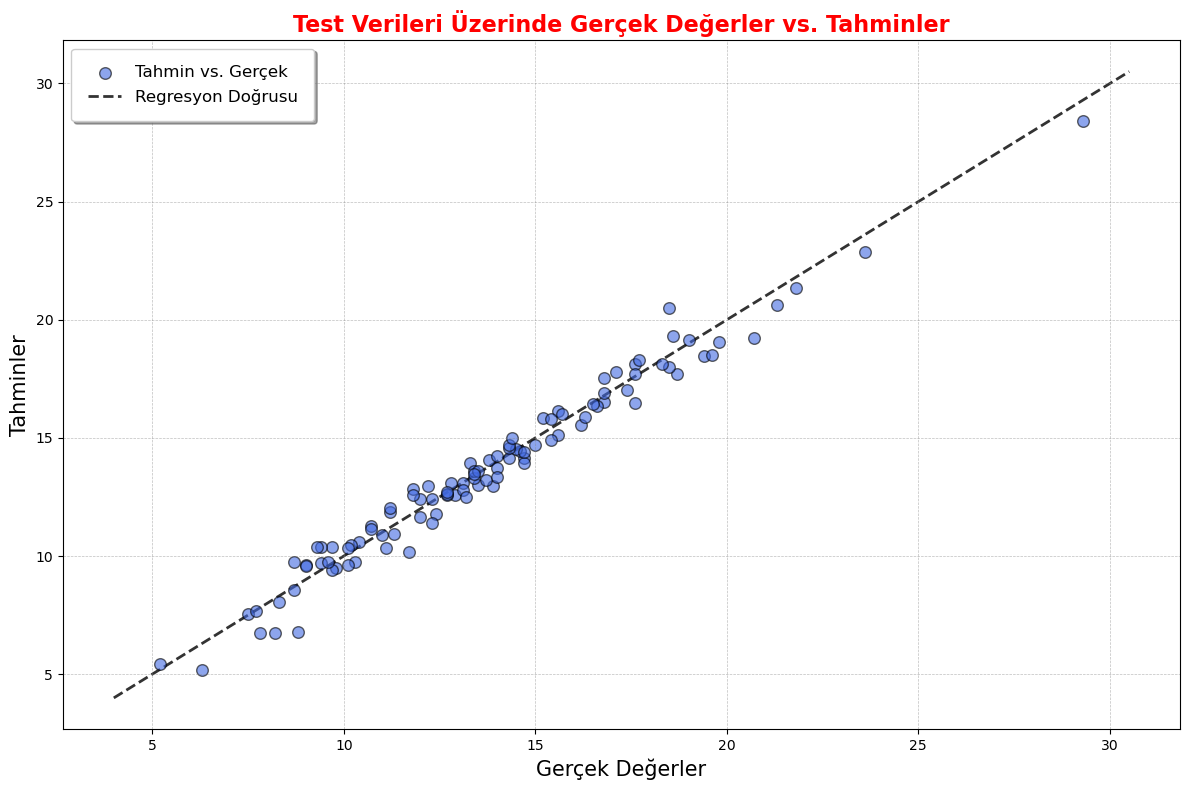

In [23]:
# Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Varsayım Kontrolleri
---

**Varsayımlar**

- 1- Tahmin hataları tesadüfidir ve Normal Dağılım gösterirler,

- 2- Tahmin hataları birbirlerinden bağımsızdır, yani hata terimleri arasında oto-korelasyon yoktur,

- 3- Her bağımsız değişkenin değerlerine ait olan bağımlı değişken değerlerinin al setlerinin 
varyansları birbirine eşittir,

- 4- Multi-Collinearity.

In [24]:
# Tahmin hataları tesadüfidir ve Normal Dağılım gösterirler
residuals = y_test - y_tahmin
statistik, p_degeri = shapiro(residuals)

print('Test İstatistiği =', statistik, ', p-değeri =', p_degeri)

# p-değeri anlamlılık düzeyine göre karar verilir
anlamlilik_duzey = 0.05
if p_degeri > anlamlilik_duzey:
    print('Normal bir dağılıma sahiptir (H0 reddedilemez)')
else:
    print('Normal bir dağılıma sahip değildir (H0 reddedilir)')

Test İstatistiği = 0.9918216049048186 , p-değeri = 0.7932234076065239
Normal bir dağılıma sahiptir (H0 reddedilemez)


In [25]:
# Tahmin hataları birbirlerinden bağımsızdır, yani hata terimleri arasında oto-korelasyon yoktur
dw_test = durbin_watson(residuals)

print(f"Durbin-Watson İstatistiği: {dw_test:.4f}")

if dw_test < 1.5:
    print("Sonuç, pozitif otokorelasyona işaret ediyor. (Düşük değerler, pozitif otokorelasyonu gösterir.)")
elif dw_test > 2.5:
    print("Sonuç, negatif otokorelasyona işaret ediyor. (Yüksek değerler, negatif otokorelasyonu gösterir.)")
else:
    print("Sonuç, hata terimleri arasında önemli bir otokorelasyon olmadığını gösteriyor. (2'ye yakın değerler, otokorelasyonun olmadığını gösterir.)")


Durbin-Watson İstatistiği: 2.0640
Sonuç, hata terimleri arasında önemli bir otokorelasyon olmadığını gösteriyor. (2'ye yakın değerler, otokorelasyonun olmadığını gösterir.)


In [26]:
# Tahmin hataları birbirlerinden bağımsızdır, yani hata terimleri arasında oto-korelasyon yoktur
dw_test = durbin_watson(residuals)

print(f"Durbin-Watson İstatistiği: {dw_test:.4f}")

if dw_test < 1.5:
    print("Sonuç, pozitif otokorelasyona işaret ediyor. (Düşük değerler, pozitif otokorelasyonu gösterir.)")
elif dw_test > 2.5:
    print("Sonuç, negatif otokorelasyona işaret ediyor. (Yüksek değerler, negatif otokorelasyonu gösterir.)")
else:
    print("Sonuç, hata terimleri arasında önemli bir otokorelasyon olmadığını gösteriyor. (2'ye yakın değerler, otokorelasyonun olmadığını gösterir.)")


Durbin-Watson İstatistiği: 2.0640
Sonuç, hata terimleri arasında önemli bir otokorelasyon olmadığını gösteriyor. (2'ye yakın değerler, otokorelasyonun olmadığını gösterir.)


In [27]:
# Multi-Collinearity
X_const = add_constant(X_train)  
vif = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("VIF Değerleri:")
sikintili_degiskenler = []
for i, v in enumerate(vif):
    print(f"Gözlem {i}: {v:.2f}")
    if v >= 5:
        sikintili_degiskenler.append((i, v))

if sikintili_degiskenler:
    print("\nYüksek VIF değerlerine sahip sıkıntılı değişkenler:")
    for degisken in sikintili_degiskenler:
        print(f"Gözlem {degisken[0]}: VIF={degisken[1]:.2f}")
    print("\nBu değişkenler modelde yüksek çoklu doğrusallık yaratıyor ve analize olumsuz etki edebilir.")
else:
    print("\nModelde önemli bir çoklu doğrusallık sorunu görünmüyor.")

VIF Değerleri:
Gözlem 0: 9586.04
Gözlem 1: 1.25
Gözlem 2: 3.01
Gözlem 3: 11.60
Gözlem 4: 16.06
Gözlem 5: 390.62
Gözlem 6: 877.72
Gözlem 7: 2224.06
Gözlem 8: 10.03
Gözlem 9: 1.51
Gözlem 10: 2.44
Gözlem 11: 7.46
Gözlem 12: 5.25
Gözlem 13: 27.44
Gözlem 14: 8.50
Gözlem 15: 2330.49
Gözlem 16: 651.30
Gözlem 17: 4299.41
Gözlem 18: 1.36

Yüksek VIF değerlerine sahip sıkıntılı değişkenler:
Gözlem 0: VIF=9586.04
Gözlem 3: VIF=11.60
Gözlem 4: VIF=16.06
Gözlem 5: VIF=390.62
Gözlem 6: VIF=877.72
Gözlem 7: VIF=2224.06
Gözlem 8: VIF=10.03
Gözlem 11: VIF=7.46
Gözlem 12: VIF=5.25
Gözlem 13: VIF=27.44
Gözlem 14: VIF=8.50
Gözlem 15: VIF=2330.49
Gözlem 16: VIF=651.30
Gözlem 17: VIF=4299.41

Bu değişkenler modelde yüksek çoklu doğrusallık yaratıyor ve analize olumsuz etki edebilir.


**Çıkarımlar**

---
- Model genel olarak normal dağılım, otokorelasyon ve homoskedastisite varsayımlarını karşılıyor, bu da modelin bu yönlerden sağlam olduğunu gösteriyor.
---
- Ancak, çoklu doğrusallık sorunu modelimin güvenilirliğini ve yorumlanabilirliğini olumsuz etkileyebilir. Bu sorunu çözmek için, yüksek VIF değerlerine sahip değişkenleri modelden çıkarabilir, birleştirebilir veya regresyon modelinde düzenlileştirme tekniklerini (örneğin, Ridge veya Lasso regresyonu) kullanabilir.
---
- Modelimi iyileştirmek için, değişken seçimi yaparken adım adım geriye eleme, ileri seçim veya her ikisinin kombinasyonu gibi değişken seçimi yöntemlerini de düşünebilir.
---
- Yüksek VIF değerlerine sahip değişkenleri daha detaylı incelemek ve bu değişkenlerin modelin rolü üzerine daha fazla analiz yapılması gerekilir.

---
### Temel Bileşenler Regresyonu (PCR)
---

In [28]:
# K-Fold Cross Validation
cv = KFold(n_splits = 10, shuffle = True, random_state = 53)

In [29]:
pca = PCA()
X_egitim_scaled = pca.fit_transform(scale(X_train))

In [30]:
# Çapraz Doğrulama Skorlarının Hesaplanması
model = LinearRegression()
scr = []
for i in np.arange(1,19):
    scr_i = -1*model_selection.cross_val_score(model, X_egitim_scaled[:, :i],
                                              y_train, cv = cv,
                                              scoring = 'neg_mean_squared_error').mean()
    scr.append(scr_i)
    
scr_df = pd.DataFrame(scr, columns=['MSE'], index=np.arange(1, 19))
print(scr_df)

             MSE
1   5.761065e+00
2   5.371976e+00
3   5.373174e+00
4   5.266109e+00
5   4.985676e+00
6   8.326290e+00
7   2.466428e+00
8   1.664386e+01
9   4.235915e+01
10  1.387681e+01
11  1.487290e+01
12  4.740575e-01
13  5.208549e-01
14  8.429933e+00
15  5.732109e+01
16  2.095955e+06
17  4.548870e+07
18  4.393186e-01


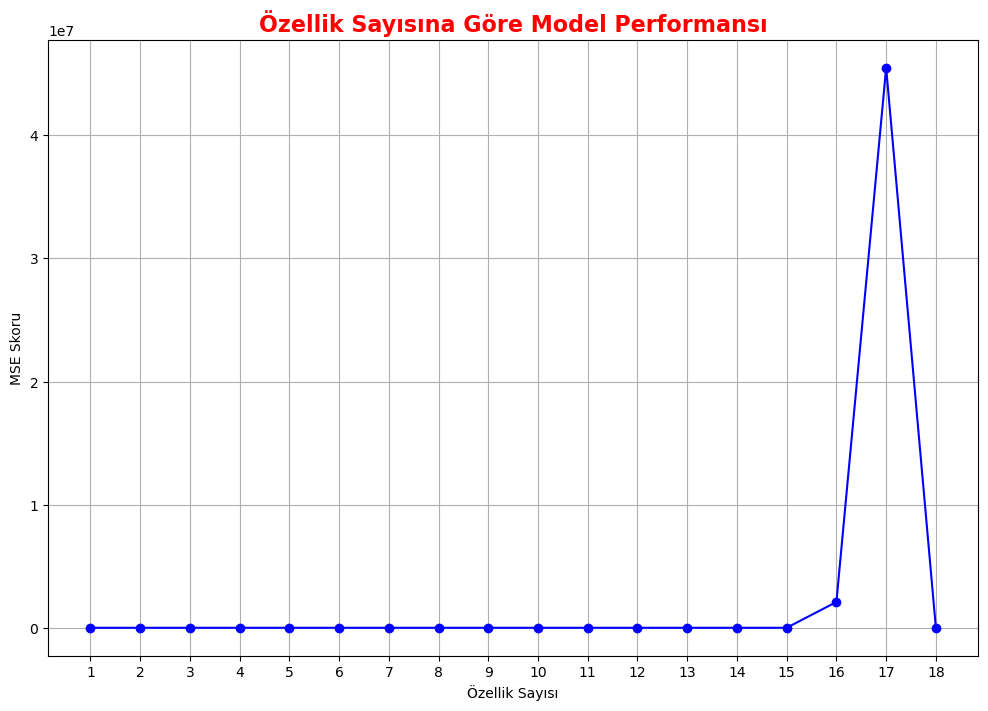

In [31]:
# Skorların Görselleştirilmesi
plt.figure(figsize=(12, 8)) 
plt.plot(np.arange(1, 19), scr, marker='o', linestyle='-', color='b')
plt.title('Özellik Sayısına Göre Model Performansı', fontsize=16, fontweight='bold', color='red')  
plt.xlabel('Özellik Sayısı') 
plt.ylabel('MSE Skoru') 
plt.grid(True)  
plt.xticks(np.arange(1, 19))  
plt.show()  

In [32]:
# Optimum Modele Ulaşma
model2 = LinearRegression()
model_pca = model2.fit(X_egitim_scaled[:, :12], y_train)
yhat = model_pca.predict(X_egitim_scaled[:, :12])
r2_in_pca = r2_score(y_train, yhat)
mse_in_pca = mean_squared_error(y_train, yhat)

print(f"PCA sonrası uygulanan lineer regresyon modelinin eğitim veri seti üzerindeki R^2 skoru: {r2_in_pca:.4f}")
print(f"PCA sonrası uygulanan lineer regresyon modelinin eğitim veri seti üzerindeki MSE değeri: {mse_in_pca:.4f}")

PCA sonrası uygulanan lineer regresyon modelinin eğitim veri seti üzerindeki R^2 skoru: 0.9798
PCA sonrası uygulanan lineer regresyon modelinin eğitim veri seti üzerindeki MSE değeri: 0.3576


In [33]:
# Out-Of-Sample Prediction
X_test_scaled = pca.fit_transform(scale(X_test))
model_pca = model2.fit(X_egitim_scaled[:, :12], y_train)
yhat2 = model_pca.predict(X_test_scaled[:, :12])

r2_out_pca = r2_score(y_test, yhat2)
mse_out_pca = mean_squared_error(y_test, yhat2)

print(f"PCA sonrası uygulanan lineer regresyon modelinin test veri seti üzerindeki R^2 skoru: {r2_out_pca:.4f}")
print(f"PCA sonrası uygulanan lineer regresyon modelinin test veri seti üzerindeki MSE değeri: {mse_out_pca:.4f}")

PCA sonrası uygulanan lineer regresyon modelinin test veri seti üzerindeki R^2 skoru: 0.0019
PCA sonrası uygulanan lineer regresyon modelinin test veri seti üzerindeki MSE değeri: 15.6086


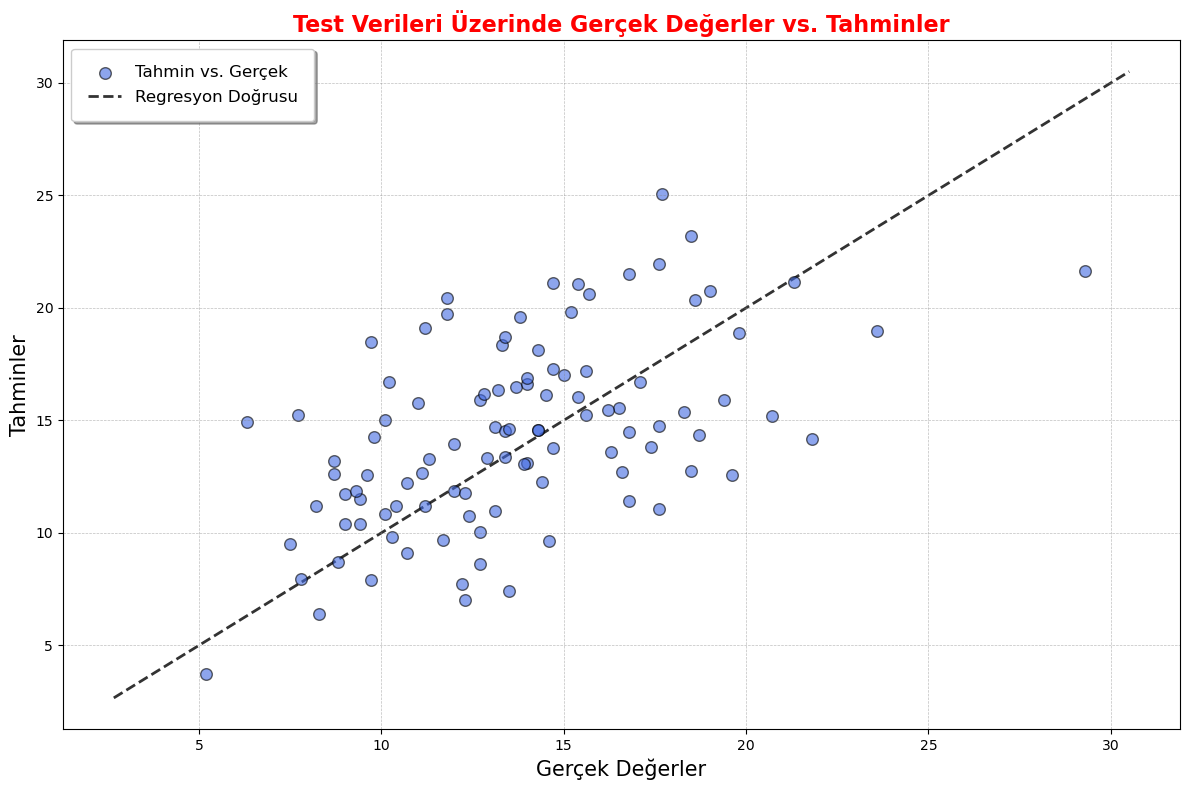

In [34]:
# Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, yhat2, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Kısmi En Küçük Kareler Regresyonu (PLS)
---

In [35]:
# PLS Modeli
pls_model_5 = PLSRegression(n_components = 5).fit(X_train, y_train)

# Tahminler
y_hat_5 = pls_model_5.predict(X_train)
y_tahmin_5 = pls_model_5.predict(X_test)

In [36]:
# Hata Metrikleri
print(f"PLS Regresyonu Eğitim Veri Seti R2 Skoru: {r2_score(y_train, y_hat_5):.4f}")
print(f"PLS Regresyonu Test Veri Seti R2 Skoru: {r2_score(y_test, y_tahmin_5):.4f}")
print(f"PLS Regresyonu Test Veri Seti Ortalama Kare Hatası (MSE): {mean_squared_error(y_test, y_tahmin_5):.4f}")
print(f"PLS Regresyonu Eğitim Veri Seti Ortalama Kare Hatası (MSE): {mean_squared_error(y_train, y_hat_5):.4f}")

PLS Regresyonu Eğitim Veri Seti R2 Skoru: 0.9783
PLS Regresyonu Test Veri Seti R2 Skoru: 0.9738
PLS Regresyonu Test Veri Seti Ortalama Kare Hatası (MSE): 0.4096
PLS Regresyonu Eğitim Veri Seti Ortalama Kare Hatası (MSE): 0.3853


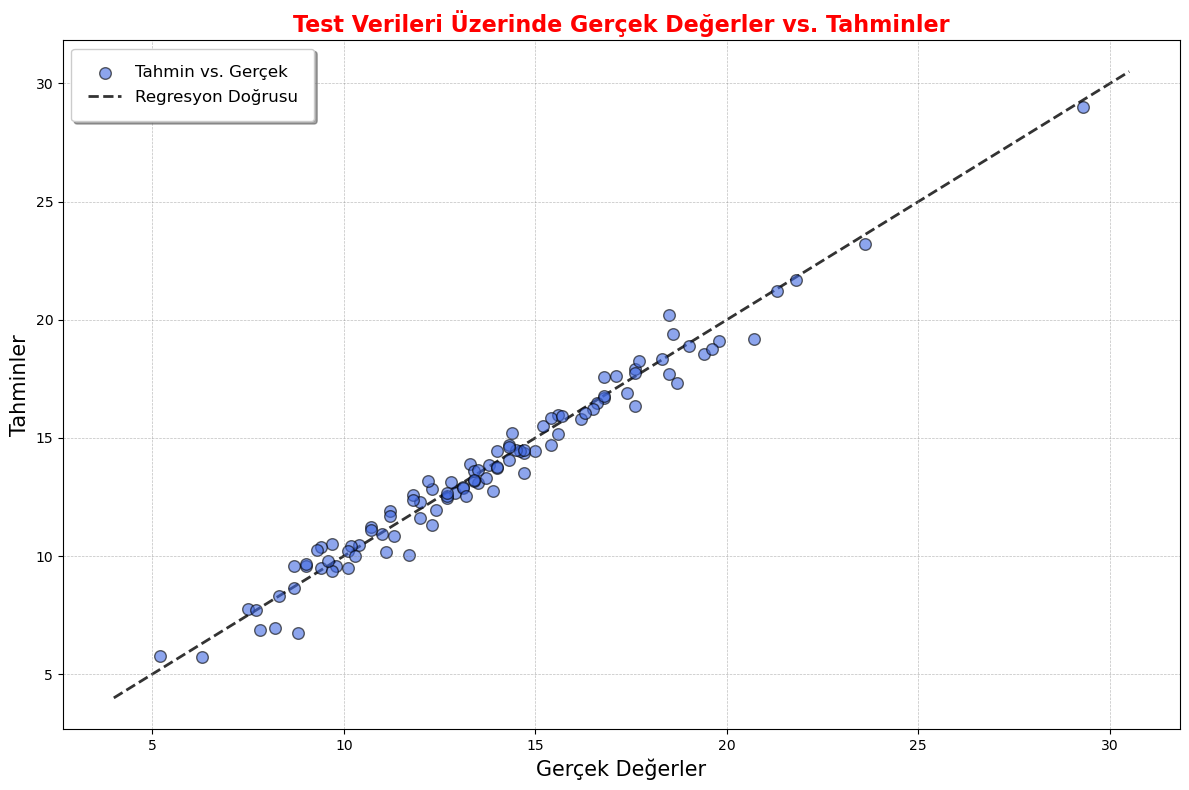

In [37]:
# Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_5, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [38]:
# Optimum PLS Skor Sayısının Belirlenmesi için Yapılacak Optimizasyon 
def optimum_pls_component(x, y, ncomp):
    model = PLSRegression(n_components = ncomp)
    cv_step = cross_val_predict(model, x, y, cv = 10)
    rscore = r2_score(y, cv_step)
    mse = mean_squared_error(y, cv_step)
    return(cv_step, rscore, mse)

In [39]:
rscore_sonuc = []
mse_sonuc = []
for i in np.arange(1,17):
    cv_step, rscore, mse = optimum_pls_component(X_train, y_train, i)
    rscore_sonuc.append(rscore)
    mse_sonuc.append(mse)
    
optimal_r2_index = np.argmax(rscore_sonuc) + 1 
optimal_mse_index = np.argmin(mse_sonuc) + 1

print("PLS Bileşen Sayısına Göre R2 ve MSE Skorları:")
for i, (rscore, mse) in enumerate(zip(rscore_sonuc, mse_sonuc), 1):
    print(f"Bileşen Sayısı = {i}: R2 Skoru = {rscore:.4f}, MSE = {mse:.4f}")

print("-" * 100)
print(f"\nEn optimal R2 skoru için bileşen sayısı = {optimal_r2_index}: R2 Skoru = {rscore_sonuc[optimal_r2_index-1]:.4f}")
print(f"En düşük MSE için bileşen sayısı = {optimal_mse_index}: MSE = {mse_sonuc[optimal_mse_index-1]:.4f}")

PLS Bileşen Sayısına Göre R2 ve MSE Skorları:
Bileşen Sayısı = 1: R2 Skoru = 0.7881, MSE = 3.7595
Bileşen Sayısı = 2: R2 Skoru = 0.9425, MSE = 1.0209
Bileşen Sayısı = 3: R2 Skoru = 0.9595, MSE = 0.7181
Bileşen Sayısı = 4: R2 Skoru = 0.9711, MSE = 0.5133
Bileşen Sayısı = 5: R2 Skoru = 0.9753, MSE = 0.4389
Bileşen Sayısı = 6: R2 Skoru = 0.9758, MSE = 0.4287
Bileşen Sayısı = 7: R2 Skoru = 0.9763, MSE = 0.4209
Bileşen Sayısı = 8: R2 Skoru = 0.9762, MSE = 0.4229
Bileşen Sayısı = 9: R2 Skoru = 0.9762, MSE = 0.4226
Bileşen Sayısı = 10: R2 Skoru = 0.9759, MSE = 0.4272
Bileşen Sayısı = 11: R2 Skoru = 0.9758, MSE = 0.4288
Bileşen Sayısı = 12: R2 Skoru = 0.9757, MSE = 0.4306
Bileşen Sayısı = 13: R2 Skoru = 0.9758, MSE = 0.4292
Bileşen Sayısı = 14: R2 Skoru = 0.9759, MSE = 0.4284
Bileşen Sayısı = 15: R2 Skoru = 0.9759, MSE = 0.4276
Bileşen Sayısı = 16: R2 Skoru = 0.9755, MSE = 0.4346
----------------------------------------------------------------------------------------------------

En optimal R2

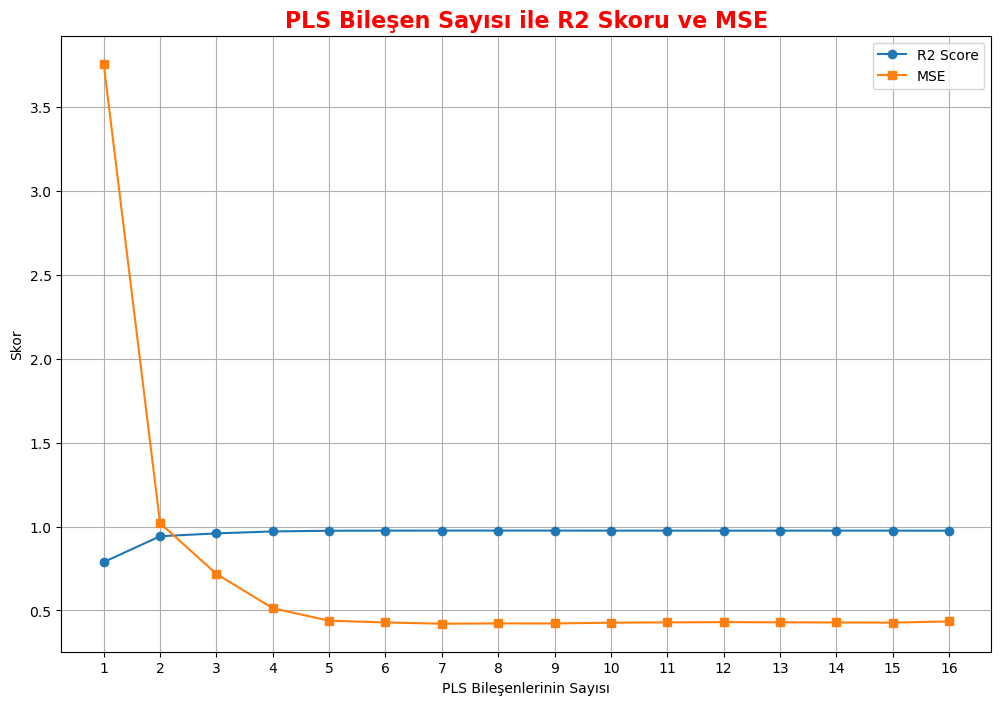

In [40]:
plt.figure(figsize=(12, 8))

plt.plot(np.arange(1, 17), rscore_sonuc, label='R2 Score', marker='o')
plt.plot(np.arange(1, 17), mse_sonuc, label='MSE', marker='s')

plt.title('PLS Bileşen Sayısı ile R2 Skoru ve MSE', color='red', fontsize=16, fontweight='bold')
plt.xlabel('PLS Bileşenlerinin Sayısı')
plt.ylabel('Skor')
plt.xticks(np.arange(1, 17))
plt.legend()
plt.grid(True)

plt.show()

In [41]:
# Optimum PLS Modeli
# PLS Modeli
pls_model_opt = PLSRegression(n_components = 7).fit(X_train, y_train)

# Tahminler
y_hat_opt = pls_model_opt.predict(X_train)
y_tahmin_opt = pls_model_opt.predict(X_test)

In [42]:
# Hata Metrikleri
print(f"Optimum PLS Regresyonu Eğitim Veri Seti R2 Skoru: {r2_score(y_train, y_hat_opt):.4f}")
print(f"Optimum PLS Regresyonu Test Veri Seti R2 Skoru: {r2_score(y_test, y_tahmin_opt):.4f}")
print(f"Optimum PLS Regresyonu Test Veri Seti Ortalama Kare Hatası (MSE): {mean_squared_error(y_test, y_tahmin_opt):.4f}")
print(f"Optimum PLS Regresyonu Eğitim Veri Seti Ortalama Kare Hatası (MSE): {mean_squared_error(y_train, y_hat_opt):.4f}")

Optimum PLS Regresyonu Eğitim Veri Seti R2 Skoru: 0.9798
Optimum PLS Regresyonu Test Veri Seti R2 Skoru: 0.9728
Optimum PLS Regresyonu Test Veri Seti Ortalama Kare Hatası (MSE): 0.4249
Optimum PLS Regresyonu Eğitim Veri Seti Ortalama Kare Hatası (MSE): 0.3586


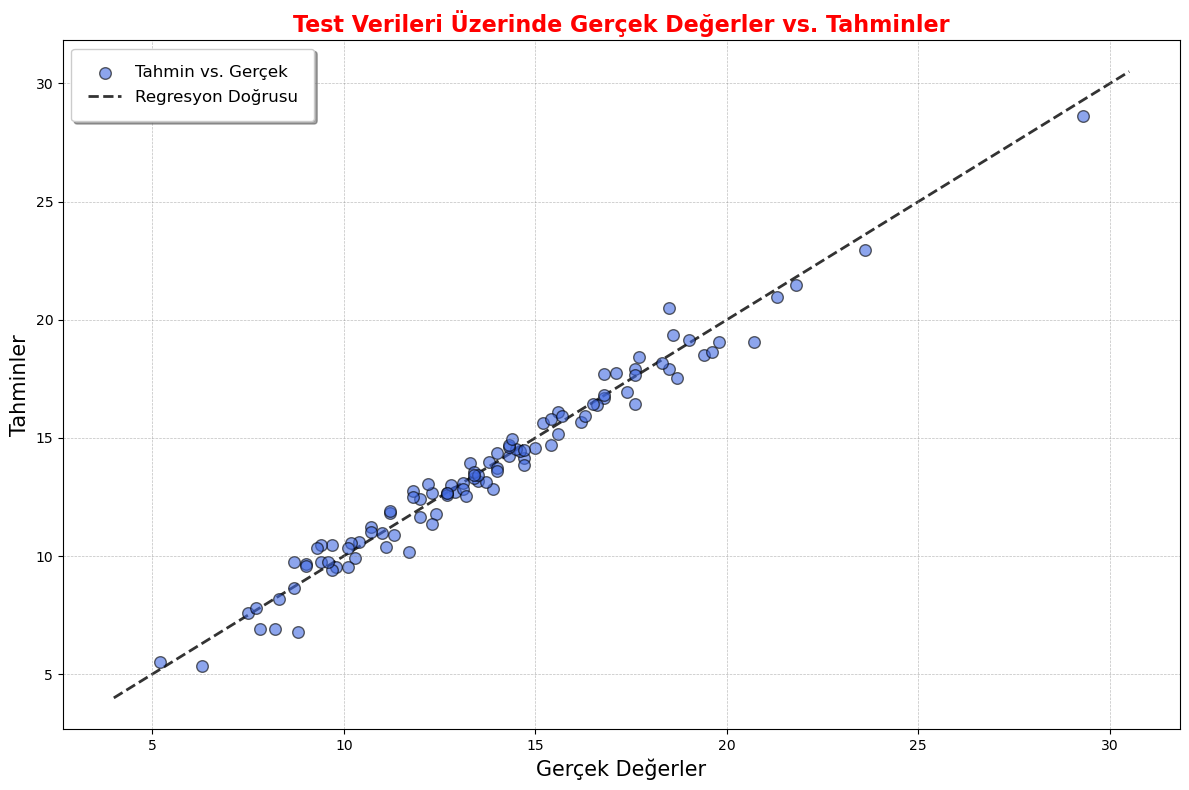

In [43]:
# Optimum Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_opt, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Ridge Regresyon (Cezalandırcı)
---

In [44]:
# Ridge Model
model_ridge = Ridge(alpha = 0.2).fit(X_train, y_train)
coef = model_ridge.coef_

feature_names = X_train.columns
coef_df = pd.DataFrame(coef, index=feature_names, columns=['Katsayılar'])

print(coef_df)

         Katsayılar
Age        0.014814
Games     -0.005924
Minutes    0.000119
TS         2.317356
ORB        0.135298
DRB        0.133609
TRB       -0.015088
AST        0.082269
STL        0.993815
BLK        0.536758
TOV       -0.037798
USG        0.459206
ORtg       0.209384
DRtg       0.009600
OWS       -0.668199
DWS       -0.944069
WS         0.972171
Outlier   -0.102889


In [45]:
y_tahmin_ridge_2 = model_ridge.predict(X_test)

r2_02 = r2_score(y_test, y_tahmin_ridge_2)
mse_02 = mean_squared_error(y_test, y_tahmin_ridge_2)

print(f"Ridge Regresyon Modeli R2_02 Skoru: {r2_02:.4f}")
print(f"Ridge Regresyon Modeli Ortalama Kare Hatası (MSE)_02: {mse_02:.4f}")

Ridge Regresyon Modeli R2_02 Skoru: 0.9730
Ridge Regresyon Modeli Ortalama Kare Hatası (MSE)_02: 0.4220


In [46]:
lambda_degerleri = np.array([0.0001, 0.005, 0.01, 0.1, 0.2, 0.5, 1, 5, 10])
# Optimum Lambda, R^2, MSE
def optimum_lambda_ve_mse(x, y, lambda_degerleri):
    model_sonuclari = []
    for lmb in lambda_degerleri:
        model = Ridge(alpha=lmb)
        cv_step = cross_val_predict(model, x, y, cv=10)
        rscore = r2_score(y, cv_step)
        mse = mean_squared_error(y, cv_step)
        model_sonuclari.append((lmb, rscore, mse))
    return model_sonuclari

model_sonuclari = optimum_lambda_ve_mse(X_train, y_train, lambda_degerleri)

optimum_lambda, _, optimum_mse = min(model_sonuclari, key=lambda x: x[2])
optimum_rscore = [rscore for lmb, rscore, mse in model_sonuclari if lmb == optimum_lambda][0]

for lmb, rscore, mse in model_sonuclari:
    print(f"Lambda = {lmb}: R2 Skoru = {rscore:.4f}, MSE = {mse:.4f}")

print(f"\nOptimum Lambda = {optimum_lambda}: Optimum R2 Skoru = {optimum_rscore:.4f}, Optimum MSE = {optimum_mse:.4f}")

Lambda = 0.0001: R2 Skoru = 0.9756, MSE = 0.4325
Lambda = 0.005: R2 Skoru = 0.9757, MSE = 0.4312
Lambda = 0.01: R2 Skoru = 0.9757, MSE = 0.4316
Lambda = 0.1: R2 Skoru = 0.9746, MSE = 0.4504
Lambda = 0.2: R2 Skoru = 0.9742, MSE = 0.4574
Lambda = 0.5: R2 Skoru = 0.9739, MSE = 0.4636
Lambda = 1.0: R2 Skoru = 0.9737, MSE = 0.4658
Lambda = 5.0: R2 Skoru = 0.9736, MSE = 0.4684
Lambda = 10.0: R2 Skoru = 0.9733, MSE = 0.4738

Optimum Lambda = 0.005: Optimum R2 Skoru = 0.9757, Optimum MSE = 0.4312


In [47]:
# Optimum Ridge Regresyonu
model_ridge_opt = Ridge(alpha = 0.005).fit(X_train, y_train)

In [48]:
y_tahmin_ridge_opt = model_ridge_opt.predict(X_test)

r2_opt = r2_score(y_test, y_tahmin_ridge_opt)
mse_opt = mean_squared_error(y_test, y_tahmin_ridge_opt)

print(f"Optimum Ridge Regresyon Modeli R2_02 Skoru: {r2_opt:.4f}")
print(f"Optimum Ridge Regresyon Modeli Ortalama Kare Hatası (MSE)_02: {mse_opt:.4f}")

Optimum Ridge Regresyon Modeli R2_02 Skoru: 0.9724
Optimum Ridge Regresyon Modeli Ortalama Kare Hatası (MSE)_02: 0.4318


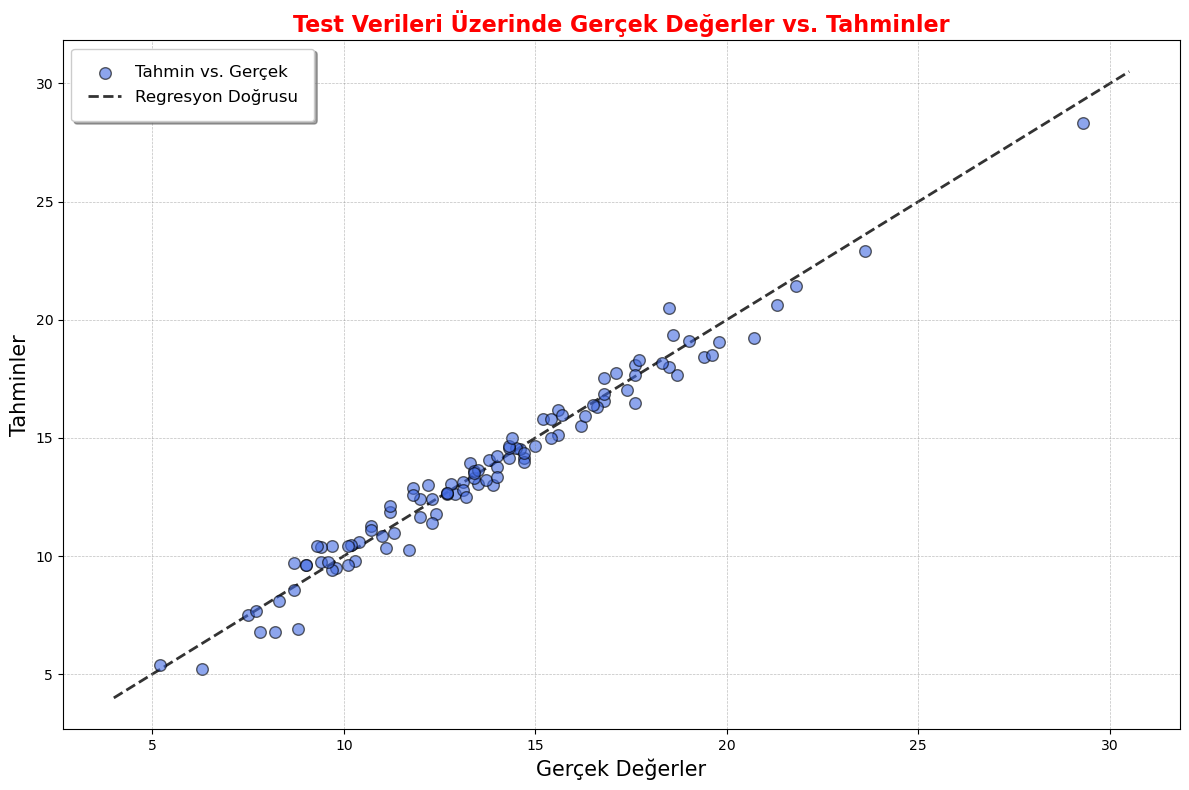

In [49]:
# Optimum Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_ridge_opt, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Lasso Regresyon
---

In [50]:
# Lasso Model
model_lasso = Lasso(alpha = 0.2).fit(X_train, y_train)
coef = model_lasso.coef_

feature_names = X_train.columns
coef_df = pd.DataFrame(coef, index=feature_names, columns=['Katsayılar'])

print(coef_df)

         Katsayılar
Age       -0.000000
Games     -0.013655
Minutes    0.000329
TS         0.000000
ORB        0.100289
DRB        0.137201
TRB        0.000000
AST        0.078801
STL        0.186301
BLK        0.305169
TOV        0.000000
USG        0.464236
ORtg       0.250103
DRtg      -0.004632
OWS        0.000000
DWS        0.000000
WS         0.172907
Outlier   -0.000000


In [51]:
y_tahmin_lasso_2 = model_lasso.predict(X_test)

r2_02 = r2_score(y_test, y_tahmin_ridge_2)
mse_02 = mean_squared_error(y_test, y_tahmin_ridge_2)

print(f"Lasso Regresyon Modeli R2_02 Skoru: {r2_02:.4f}")
print(f"Lasso Regresyon Modeli Ortalama Kare Hatası (MSE)_02: {mse_02:.4f}")

Lasso Regresyon Modeli R2_02 Skoru: 0.9730
Lasso Regresyon Modeli Ortalama Kare Hatası (MSE)_02: 0.4220


In [52]:
# Model Optimazyonu
model_lasso_cv = LassoCV(cv = 10, random_state=1, max_iter = 1000)
model_lasso_cv.fit(X_train, y_train)

LassoCV(cv=10, random_state=1)

In [53]:
opt_alpha = model_lasso_cv.alpha_
print(f"Optimum Alpha: {opt_alpha}")

optimum_model_lasso = Lasso(alpha=opt_alpha).fit(X_train, y_train)
y_tahmin_opt = optimum_model_lasso.predict(X_test)

r2_opt = r2_score(y_test, y_tahmin_opt)
mse_opt = mean_squared_error(y_test, y_tahmin_opt)

print(f"Optimum Lasso Modeli R2 Skoru: {r2_opt:.4f}")
print(f"Optimum Lasso Modeli MSE: {mse_opt:.4f}")

Optimum Alpha: 1.7110933772167858
Optimum Lasso Modeli R2 Skoru: 0.9071
Optimum Lasso Modeli MSE: 1.4535


In [54]:
# Optimum Model
model_lasso_opt = Lasso(alpha =  1.7110933772167858).fit(X_train, y_train)
y_tahmin_lasso_opt = model_lasso_opt.predict(X_test)

r2__opt = r2_score(y_test, y_tahmin_opt)
mse__opt = mean_squared_error(y_test, y_tahmin_opt)

print(f"Lasso Regresyon Modeli R2_02 Skoru: {r2__opt:.4f}")
print(f"Lasso Regresyon Modeli Ortalama Kare Hatası (MSE)_02: {mse__opt:.4f}")

Lasso Regresyon Modeli R2_02 Skoru: 0.9071
Lasso Regresyon Modeli Ortalama Kare Hatası (MSE)_02: 1.4535


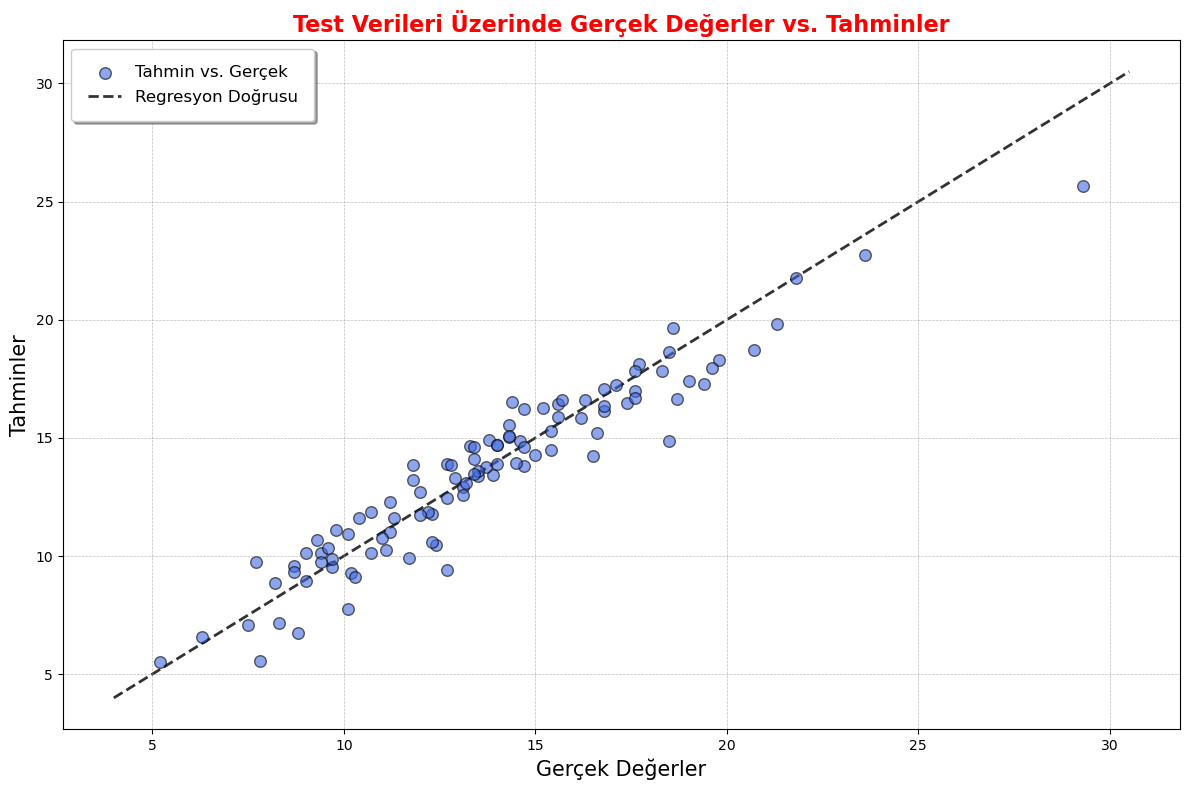

In [55]:
# Optimum Tahminler
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_lasso_opt, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
###  KNN Regresyonu 
---

In [56]:
# KNN Model
KNN_model = KNeighborsRegressor().fit(X_train, y_train)
print(f"KNN Modelinin Komşu Sayısı: {KNN_model.n_neighbors}")

KNN Modelinin Komşu Sayısı: 5


In [57]:
y_hat_5 = KNN_model.predict(X_train)
y_hat_5_tahmin = KNN_model.predict(X_test)

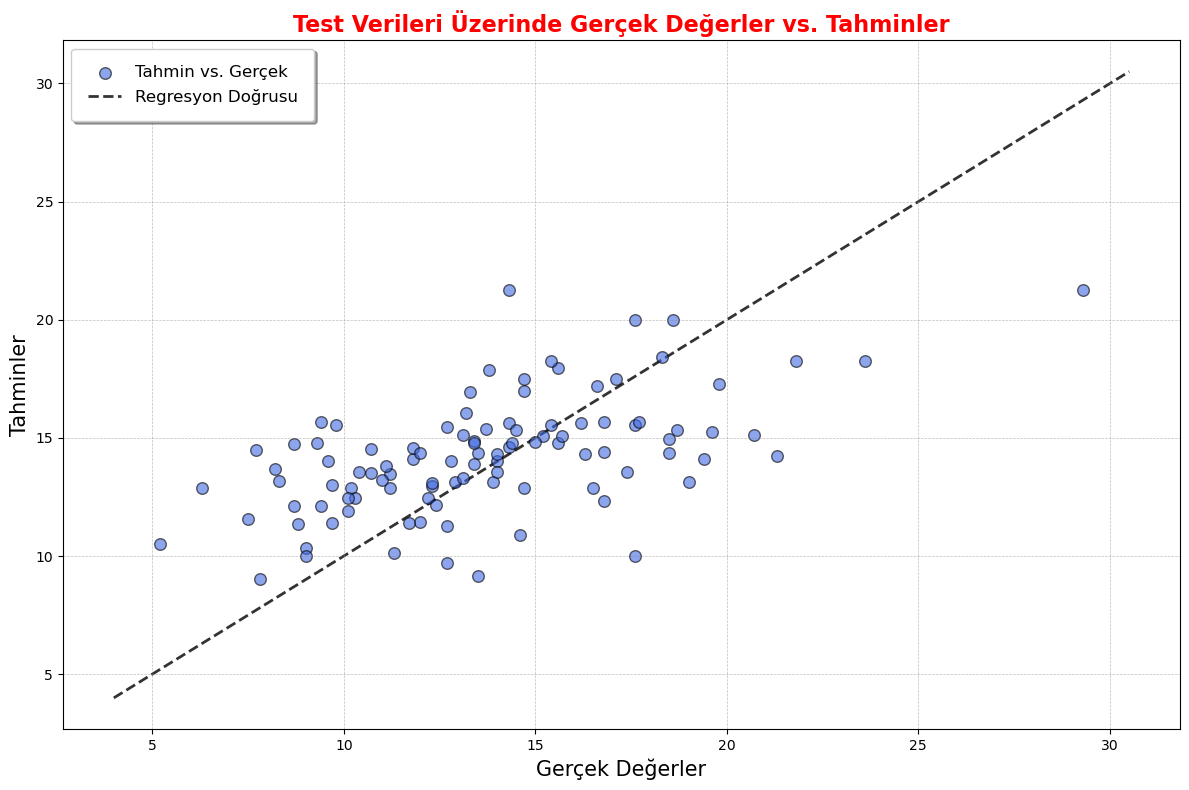

In [58]:
# K = 5 İçin
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_hat_5_tahmin, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [59]:
r2_egitim_knn5 = r2_score(y_train, y_hat_5)
r2_test_knn5 = r2_score(y_test, y_hat_5_tahmin)
mse_egitim_knn5 = mean_squared_error(y_train, y_hat_5)
mse_test_knn5 = mean_squared_error(y_test, y_hat_5_tahmin)

print(f"Default KNN Eğitim Veri Seti R2 Skoru: {r2_egitim_knn5:.4f}")
print(f"Default KNN Test Veri Seti R2 Skoru: {r2_test_knn5:.4f}")
print(f"Default KNN Eğitim Veri Seti MSE: {mse_egitim_knn5:.4f}")
print(f"Default KNN Test Veri Seti MSE: {mse_test_knn5:.4f}")


Default KNN Eğitim Veri Seti R2 Skoru: 0.5039
Default KNN Test Veri Seti R2 Skoru: 0.3042
Default KNN Eğitim Veri Seti MSE: 8.8019
Default KNN Test Veri Seti MSE: 10.8819


In [60]:
# Model Optimizasyonu
mse_degerleri = []
r2_degerleri = []

for k in range(15):
    k = k + 1
    KNN_model_k = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    y_hat_k = KNN_model_k.predict(X_train)
    r2_k = r2_score(y_train, y_hat_k)
    mse_k = mean_squared_error(y_train, y_hat_k)
    r2_degerleri.append(r2_k)
    mse_degerleri.append(mse_k)
    

print("K Değerine Göre Eğitim Veri Setinin R2 ve MSE Skorları:")
for k, (r2, mse) in enumerate(zip(r2_degerleri, mse_degerleri), 1):
    print(f"K = {k}: R2 Skoru = {r2:.4f}, MSE = {mse:.4f}")


K Değerine Göre Eğitim Veri Setinin R2 ve MSE Skorları:
K = 1: R2 Skoru = 1.0000, MSE = 0.0000
K = 2: R2 Skoru = 0.7692, MSE = 4.0955
K = 3: R2 Skoru = 0.6312, MSE = 6.5447
K = 4: R2 Skoru = 0.5549, MSE = 7.8971
K = 5: R2 Skoru = 0.5039, MSE = 8.8019
K = 6: R2 Skoru = 0.4589, MSE = 9.6016
K = 7: R2 Skoru = 0.4392, MSE = 9.9513
K = 8: R2 Skoru = 0.4313, MSE = 10.0911
K = 9: R2 Skoru = 0.4008, MSE = 10.6328
K = 10: R2 Skoru = 0.3868, MSE = 10.8808
K = 11: R2 Skoru = 0.3732, MSE = 11.1212
K = 12: R2 Skoru = 0.3701, MSE = 11.1770
K = 13: R2 Skoru = 0.3571, MSE = 11.4079
K = 14: R2 Skoru = 0.3510, MSE = 11.5158
K = 15: R2 Skoru = 0.3476, MSE = 11.5757


In [61]:
# Grid Search ile Optimum K'nın Belirlenmesi
KNN_model_gs = KNeighborsRegressor()
aday_k = {"n_neighbors": [2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
KNN_model_grid = GridSearchCV(KNN_model_gs, aday_k, cv = 10)
KNN_model_grid.fit(X_train, y_train)


print(f"Grid Search ile Bulunan En İyi K Değeri: {KNN_model_grid.best_params_['n_neighbors']}")

Grid Search ile Bulunan En İyi K Değeri: 13


In [62]:
KNN_model_opt = KNeighborsRegressor(n_neighbors=13).fit(X_train, y_train)
y_hat_13 = KNN_model_opt.predict(X_train)
y_hat_13_tahmin = KNN_model_opt.predict(X_test)


r2_test_knnopt = r2_score(y_test, y_hat_13_tahmin)
mse_test_knnopt = mean_squared_error(y_test, y_hat_13_tahmin)

print(f"Optimum KNN Test Veri Seti R2 Skoru: {r2_test_knnopt:.4f}")
print(f"Optimum KNN Test Veri Seti MSE: {mse_test_knnopt:.4f}")


Optimum KNN Test Veri Seti R2 Skoru: 0.2365
Optimum KNN Test Veri Seti MSE: 11.9393


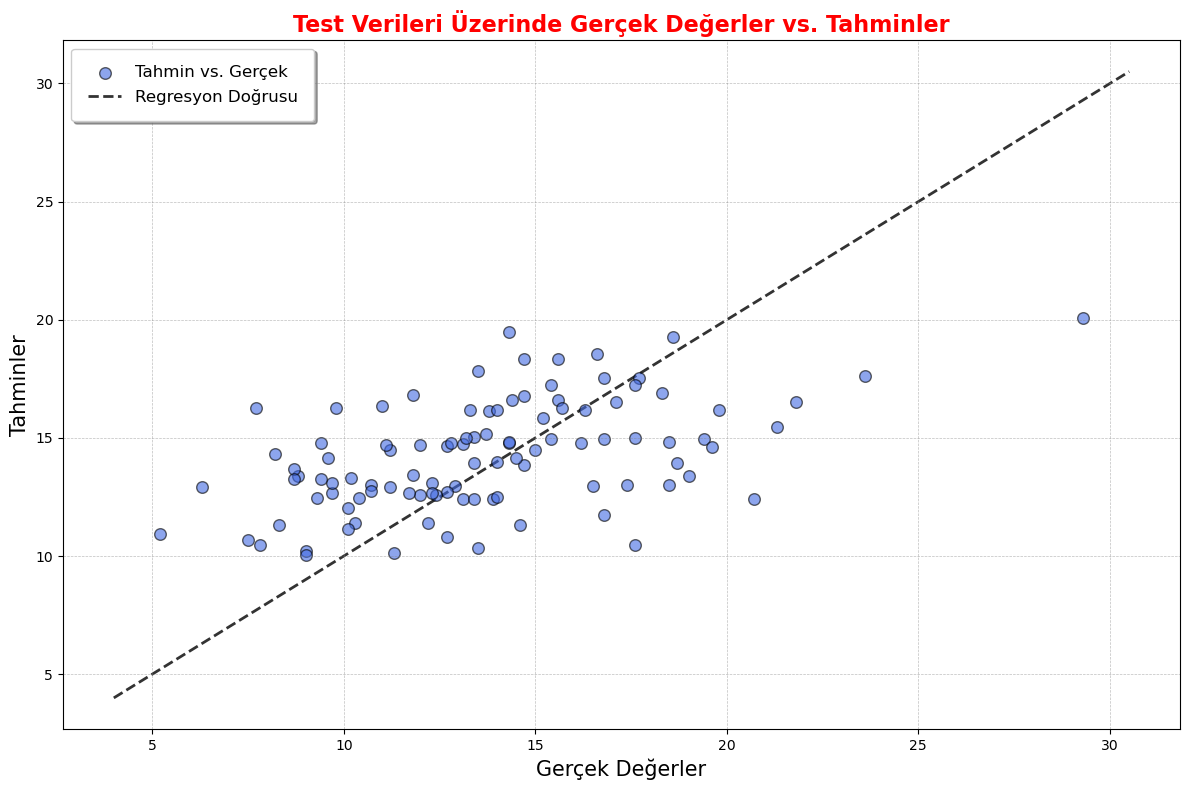

In [63]:
# Optimum Model 
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_hat_13_tahmin, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
###  Support Vector Machine (Karar Destek Vektörleri) 
--- 

In [64]:
# Doğrusal Model
SVR_model_dogrusal = SVR(kernel="linear").fit(X_train, y_train)
y_hat = SVR_model_dogrusal.predict(X_train)
y_tahmin = SVR_model_dogrusal.predict(X_test)

# R2 ve MSE skorları
r2_test = r2_score(y_test, y_tahmin)
mse_test = mean_squared_error(y_test, y_tahmin)

print(f"Doğrusal SVR Modeli Test Veri Seti R2 Skoru: {r2_test:.4f}")
print(f"Doğrusal SVR Modeli Test Veri Seti için MSE Skoru: {mse_test:.4f}")

Doğrusal SVR Modeli Test Veri Seti R2 Skoru: 0.9548
Doğrusal SVR Modeli Test Veri Seti için MSE Skoru: 0.7065


In [65]:
# Doğrusal Olmayan Model
SVR_model_nn = SVR(kernel = "rbf").fit(X_train, y_train)
y_hat_nn = SVR_model_nn.predict(X_train)
y_tahmin_nn = SVR_model_nn.predict(X_test)

# Doğrusal olmayan model için ve Test veri setlerinin R2 ve MSE skorları
r2_test_nn = r2_score(y_test, y_tahmin_nn)
mse_test_nn = mean_squared_error(y_test, y_tahmin_nn)

print(f"Doğrusal Olmayan SVR Modeli Test Veri Seti R2 Skoru: {r2_test_nn:.4f}")
print(f"Doğrusal Olmayan SVR Modeli Test Veri Seti için MSE Skoru: {mse_test_nn:.4f}")

Doğrusal Olmayan SVR Modeli Test Veri Seti R2 Skoru: 0.2405
Doğrusal Olmayan SVR Modeli Test Veri Seti için MSE Skoru: 11.8771


---
###  Yapay Sinir Ağları (Artificial Neural Network, ANN) 
---

In [66]:
# Model
scl = StandardScaler()
scl.fit(X_train)
X_egitim_scale = scl.transform(X_train)
X_test_scale = scl.transform(X_test)

In [67]:
ysa_modeli =  MLPRegressor().fit(X_egitim_scale, y_train)

print("Model Mimarisi:")
print(f"Modeldeki katman sayısı: {ysa_modeli.n_layers_}")
print(f"Gizli katmanların boyutu: {ysa_modeli.hidden_layer_sizes}")

Model Mimarisi:
Modeldeki katman sayısı: 3
Gizli katmanların boyutu: (100,)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [68]:
y_tahmin = ysa_modeli.predict(X_test_scale)

r2_ysa = r2_score(y_test, y_tahmin)
mse_ysa = mean_squared_error(y_test, y_tahmin)

print(f"ANN Modeli R2 Skoru: {r2_ysa:.4f}")
print(f"ANN Modeli MSE: {mse_ysa:.4f}")

ANN Modeli R2 Skoru: 0.2777
ANN Modeli MSE: 11.2964


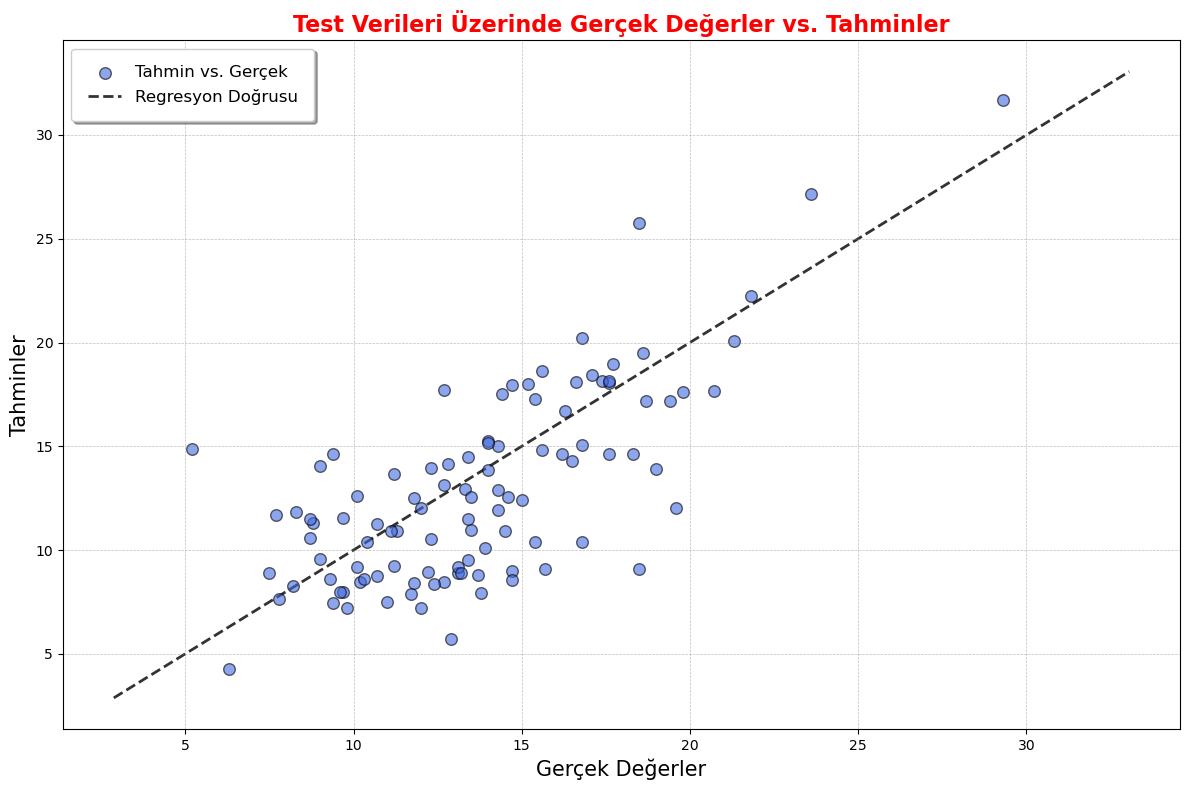

In [69]:
# Deafult Model Grafik
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [70]:
# Model Optimizasyonu
parametreler = {"alpha": [0.1, 0.01, 0.02, 0.005],
               "hidden_layer_sizes": [(20,20), (100, 25, 150), (250, 100, 200)],
               "activation": ["relu", "logistic"]}

gs_ann_model = GridSearchCV(ysa_modeli, parametreler, cv = 5)
gs_ann_model.fit(X_egitim_scale, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_

GridSearchCV(cv=5, estimator=MLPRegressor(),
             param_grid={'activation': ['relu', 'logistic'],
                         'alpha': [0.1, 0.01, 0.02, 0.005],
                         'hidden_layer_sizes': [(20, 20), (100, 25, 150),
                                                (250, 100, 200)]})

In [71]:
print(f"Yapay Sinir Ağları Modeli için En İyi Parametreler: {gs_ann_model.best_params_}")

Yapay Sinir Ağları Modeli için En İyi Parametreler: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (250, 100, 200)}


In [72]:
# Optimum Model
best_ann_model = MLPRegressor(alpha = 0.02, hidden_layer_sizes = (250, 100, 200), 
                              activation = "relu").fit(X_egitim_scale, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [73]:
best_tahmin = best_ann_model.predict(X_test_scale)

best_r2 = r2_score(y_test, best_tahmin)
best_mse = mean_squared_error(y_test, best_tahmin)

print(f"En İyi ANN Modeli R2 Skoru: {best_r2:.4f}")
print(f"En İyi ANN Modeli MSE: {best_mse:.4f}")

En İyi ANN Modeli R2 Skoru: 0.9431
En İyi ANN Modeli MSE: 0.8897


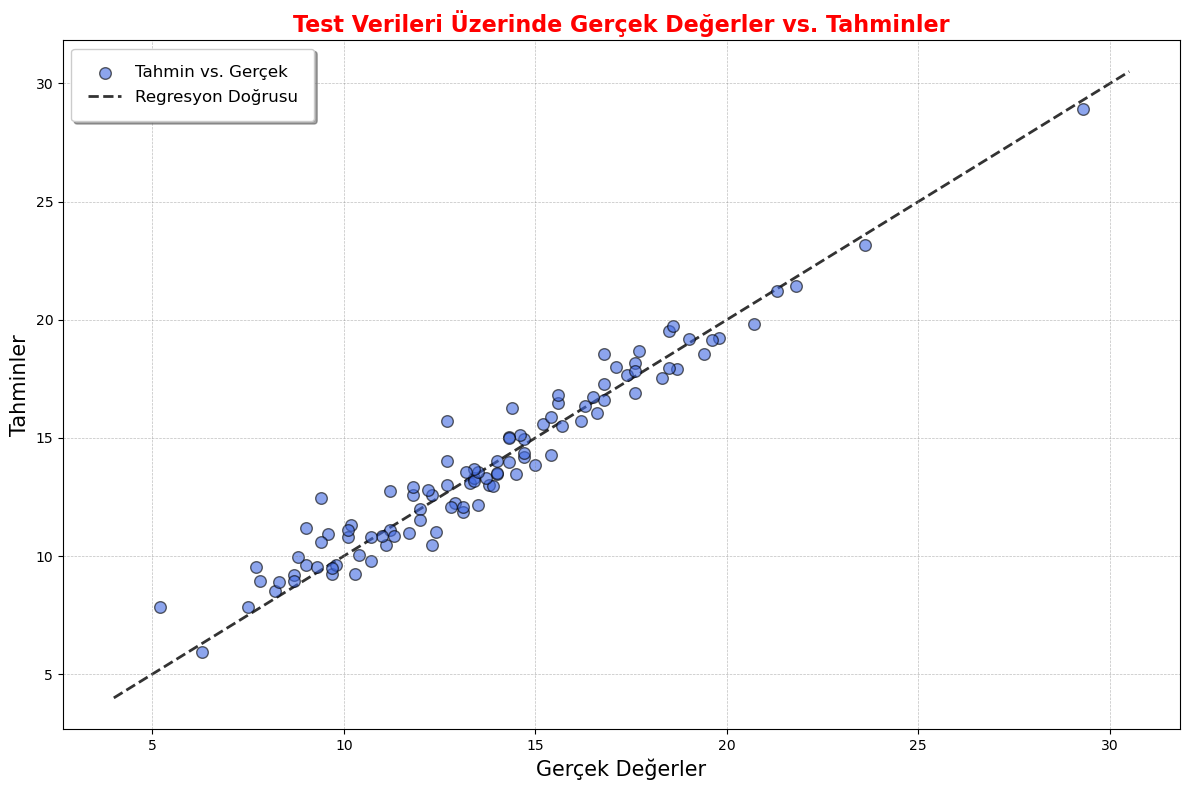

In [74]:
y_true_ann = y_test  
y_pred_ann = best_tahmin
# Optimum
plt.figure(figsize=(12, 8))
plt.scatter(y_test, best_tahmin, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Karar Ağaçları
---

In [75]:
# Cart Uygulaması, default 
cart_model0 = DecisionTreeRegressor().fit(X_train, y_train)
y_tahmin0 = cart_model0.predict(X_test)
r2_skoru_default = r2_score(y_test, y_tahmin0)
mse_default  = mean_squared_error(y_test, y_tahmin0)

print(f"Karar Ağacı Default R^2 Skoru: {r2_skoru_default:.4f}")
print(f"Karar Ağacı Default (Ortalama Kare Hata): {mse_default:.4f}")

Karar Ağacı Default R^2 Skoru: 0.6720
Karar Ağacı Default (Ortalama Kare Hata): 5.1287


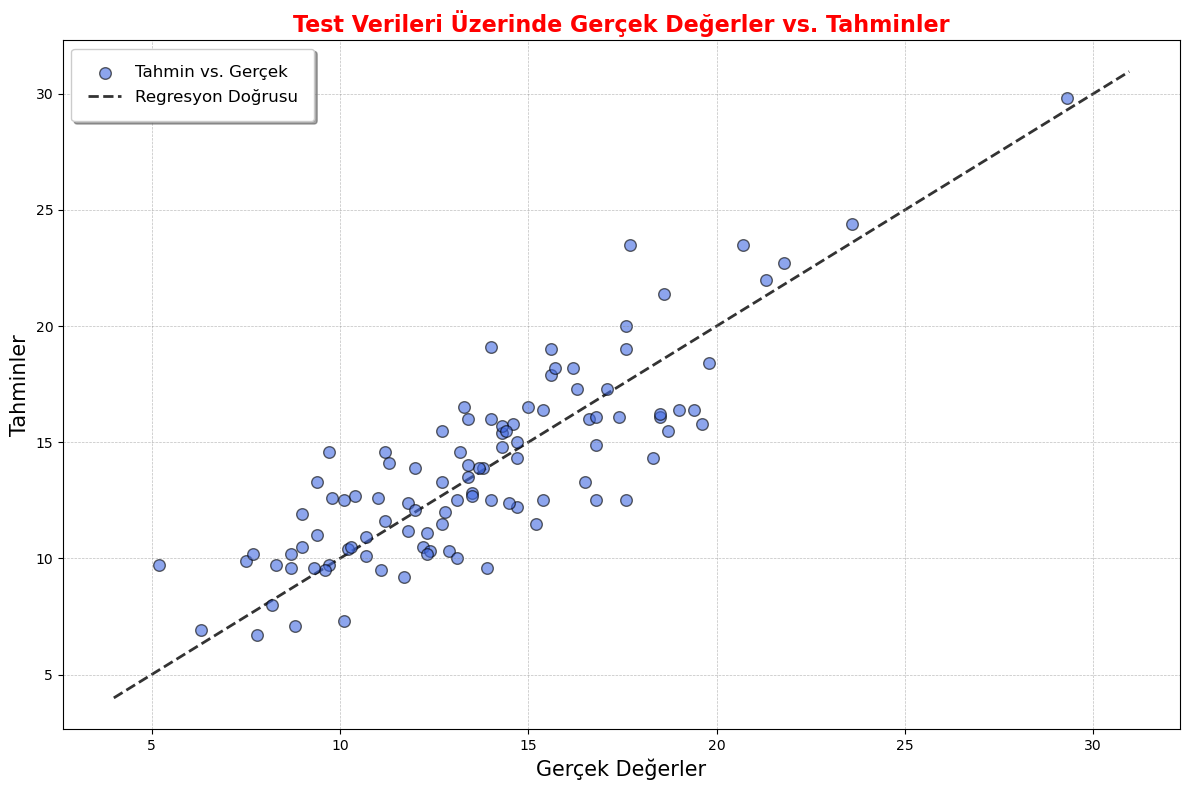

In [76]:
# Default Model Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin0, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [77]:
# Model Optimizasyonu
parametreler = {
    "min_samples_split": range(2, 100),  
    "max_leaf_nodes": range(2, 10)  
}

GS_cart = GridSearchCV(cart_model0, parametreler, cv = 10).fit(X_train, y_train)
print("En iyi parametreler:", GS_cart.best_params_)

En iyi parametreler: {'max_leaf_nodes': 9, 'min_samples_split': 40}


In [78]:
# Optimizasyon Sonucunda Elde Edilen En İyi Parametrelerle Modelin Oluşturulması
optim_cart = DecisionTreeRegressor(max_leaf_nodes=9, min_samples_split=40).fit(X_train, y_train)
y_tahmin_optim = optim_cart.predict(X_test)

r2_skoru_optimcart = r2_score(y_test, y_tahmin_optim)
mse_degeri_optimcart = mean_squared_error(y_test, y_tahmin_optim)

print(f"Optimum Karar Ağacı Modeli R^2 Skoru: {r2_skoru_optimcart:.4f}")
print(f"Optimum Karar Ağacı Modeli MSE Değeri: {mse_degeri_optimcart:.4f}")

Optimum Karar Ağacı Modeli R^2 Skoru: 0.6762
Optimum Karar Ağacı Modeli MSE Değeri: 5.0637


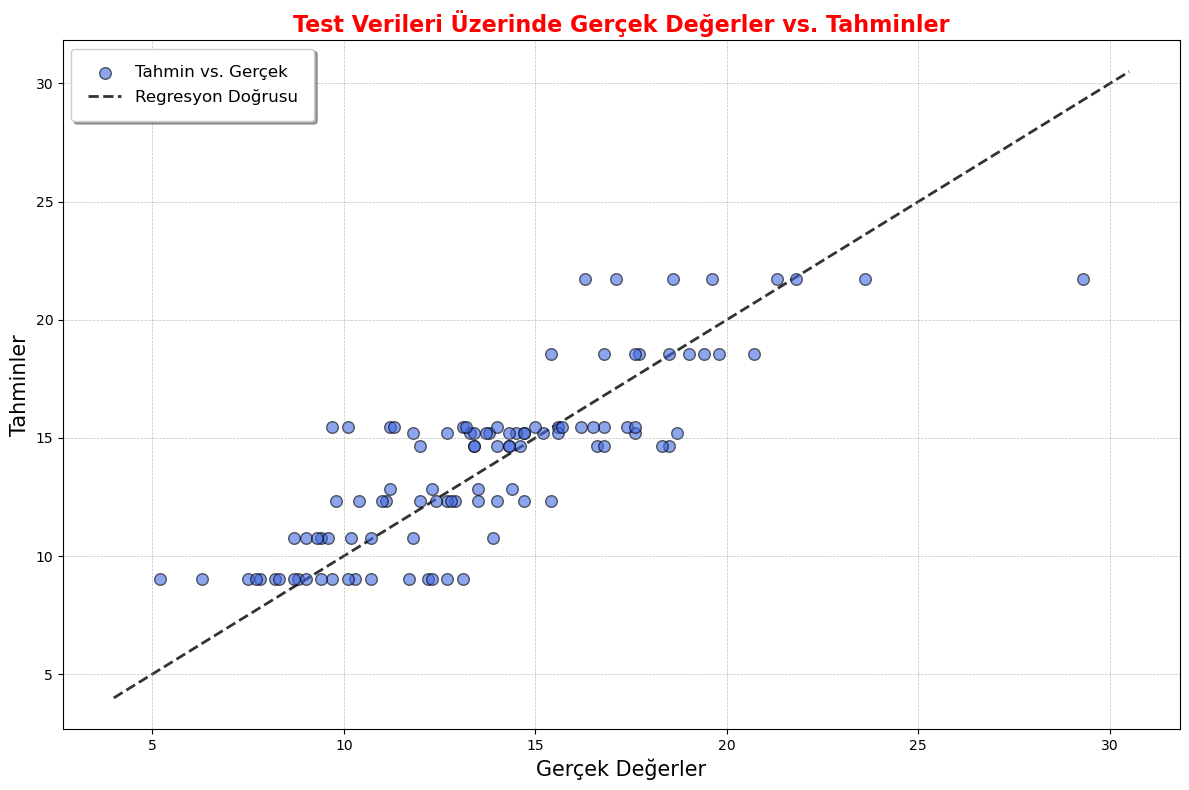

In [79]:
# Optimum Model Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_optim, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Bagging 
---

In [80]:
# Bagging default 
bag_model0 = BaggingRegressor(bootstrap=True).fit(X_train, y_train)
y_tahmin_bag = bag_model0.predict(X_test)
r2_skoru_default = r2_score(y_test, y_tahmin0)
mse_default = mean_squared_error(y_test, y_tahmin0)

print(f"Bagging Default Modeli R^2 Skoru: {r2_skoru_default:.4f}")
print(f"Bagging Default Modeli MSE (Ortalama Kare Hata): {mse_default:.4f}")

Bagging Default Modeli R^2 Skoru: 0.6720
Bagging Default Modeli MSE (Ortalama Kare Hata): 5.1287


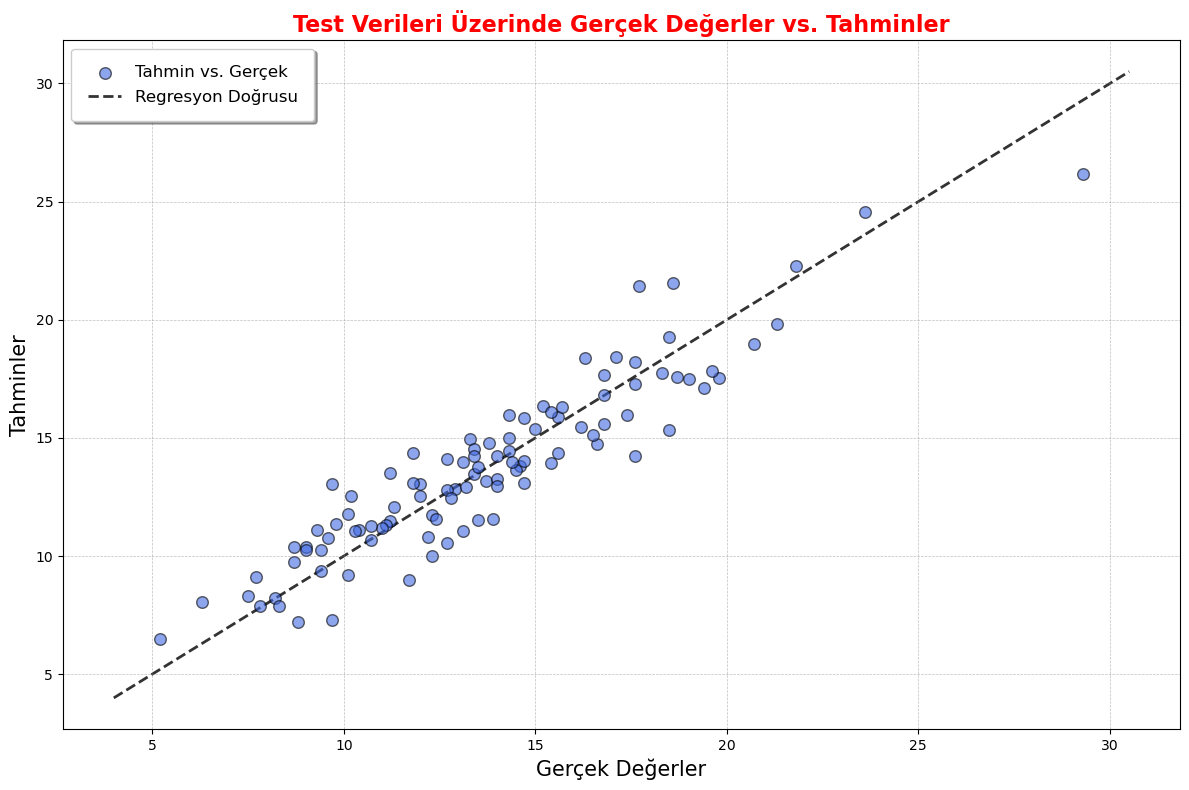

In [81]:
# Bagging default  Scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_bag, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [82]:
bag_params = {"n_estimators": range(2,100)}
GS_bag = GridSearchCV(bag_model0, bag_params, cv = 10).fit(X_train, y_train)
best_params = GS_bag.best_params_
print("Bagging Regressor için En İyi Parametreler:")
print(best_params)

Bagging Regressor için En İyi Parametreler:
{'n_estimators': 58}


In [83]:
# Optimizasyon Sonucunda Elde Edilen En İyi Parametrelerle Modelin Oluşturulması
best_bag = BaggingRegressor(n_estimators=85).fit(X_train, y_train)
y_tahmin_best_bag = best_bag.predict(X_test)

r2_skoru_optimbag = r2_score(y_test, y_tahmin_best_bag)
mse_degeri_optimbag = mean_squared_error(y_test, y_tahmin_best_bag)

print(f"Optimum Bagging Modeli R^2 Skoru: {r2_skoru_optimbag:.4f}")
print(f"Optimum Bagging Modeli MSE Değeri: {mse_degeri_optimbag:.4f}")

Optimum Bagging Modeli R^2 Skoru: 0.8736
Optimum Bagging Modeli MSE Değeri: 1.9767


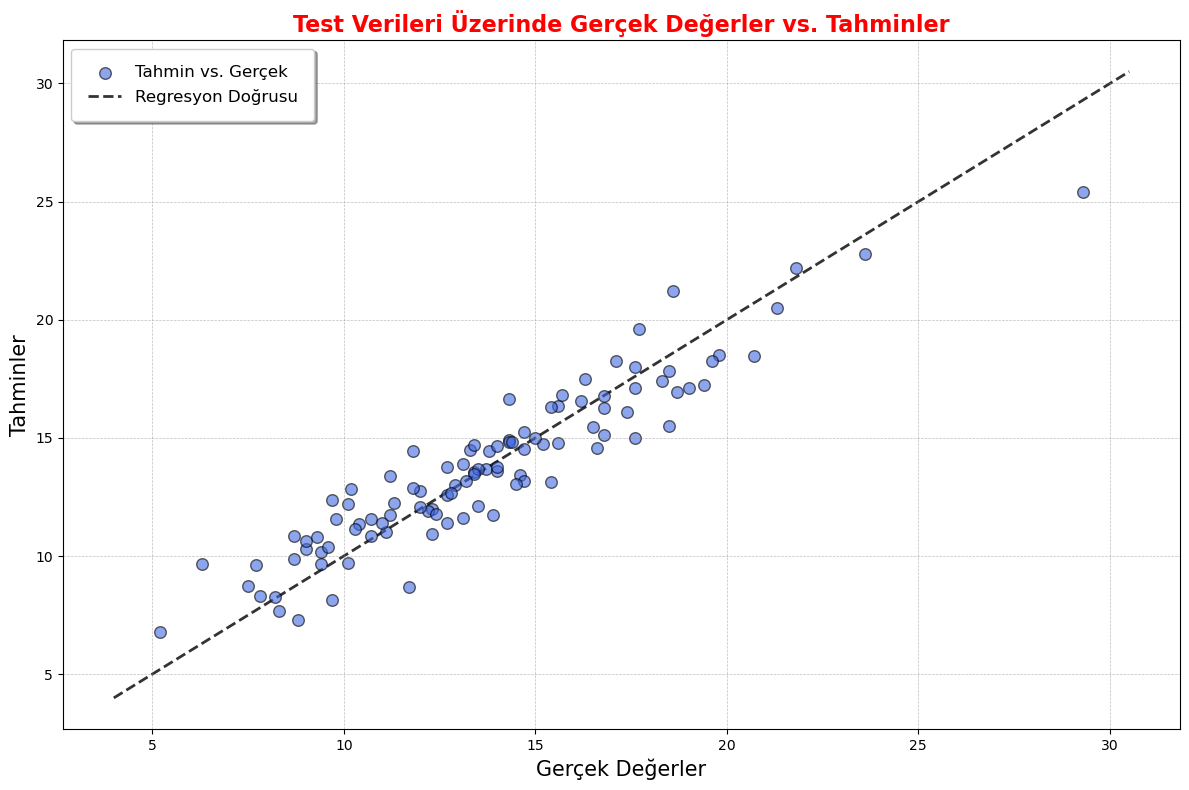

In [84]:
# Bagging Optimum Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_best_bag, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
###  Random Forest
---

In [85]:
# Random Forest default
rf_model0 = RandomForestRegressor().fit(X_train, y_train)
y_tahmin_drf = rf_model0.predict(X_test)
r2_skoru_default = r2_score(y_test, y_tahmin_drf)
mse_default  = mean_squared_error(y_test, y_tahmin_drf)

print(f"Random Forest Default R^2 Skoru: {r2_skoru_default:.4f}")
print(f"Random Forest Default MSE (Ortalama Kare Hata): {mse_default:.4f}")

Random Forest Default R^2 Skoru: 0.8681
Random Forest Default MSE (Ortalama Kare Hata): 2.0633


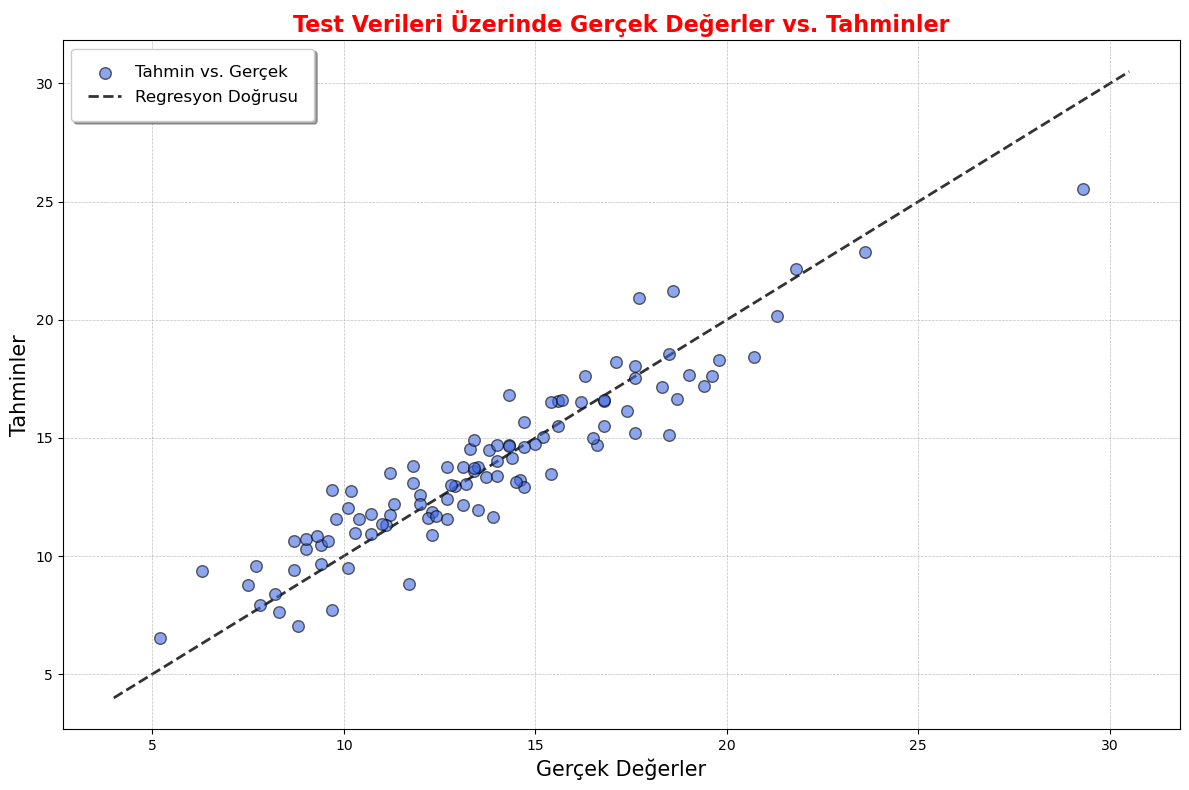

In [86]:
# Random Forest Default Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_drf, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [87]:
# Model Optimizasyonu
rf_params = {"max_depth": range(1,15), "max_features": [2,3,5,10,15],
             "n_estimators": [25, 50, 100, 200, 1000]}

In [88]:
GS_rf = GridSearchCV(rf_model0, rf_params, cv = 2).fit(X_train, y_train)
best_params = GS_rf.best_params_
print("Random Forest Regressor için En İyi Parametreler:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Random Forest Regressor için En İyi Parametreler:
max_depth: 9
max_features: 10
n_estimators: 200


In [89]:
# Optimum model
rf_optim = RandomForestRegressor(max_depth=13, max_features=15, n_estimators=100).fit(X_train, y_train)
y_pred_optim_rf = rf_optim.predict(X_test)

r2_opt_rf = r2_score(y_test, y_pred_optim_rf)
mse_opt_rf = mean_squared_error(y_test, y_pred_optim_rf)

print(f"Optimum Random Forest Modeli R^2 (R-squared) Değeri: {r2_opt_rf:.4f}")
print(f"Optimum Random Forest Modeli MSE (Ortalama Karesel Hata): {mse_opt_rf:.4f}")

Optimum Random Forest Modeli R^2 (R-squared) Değeri: 0.8739
Optimum Random Forest Modeli MSE (Ortalama Karesel Hata): 1.9712


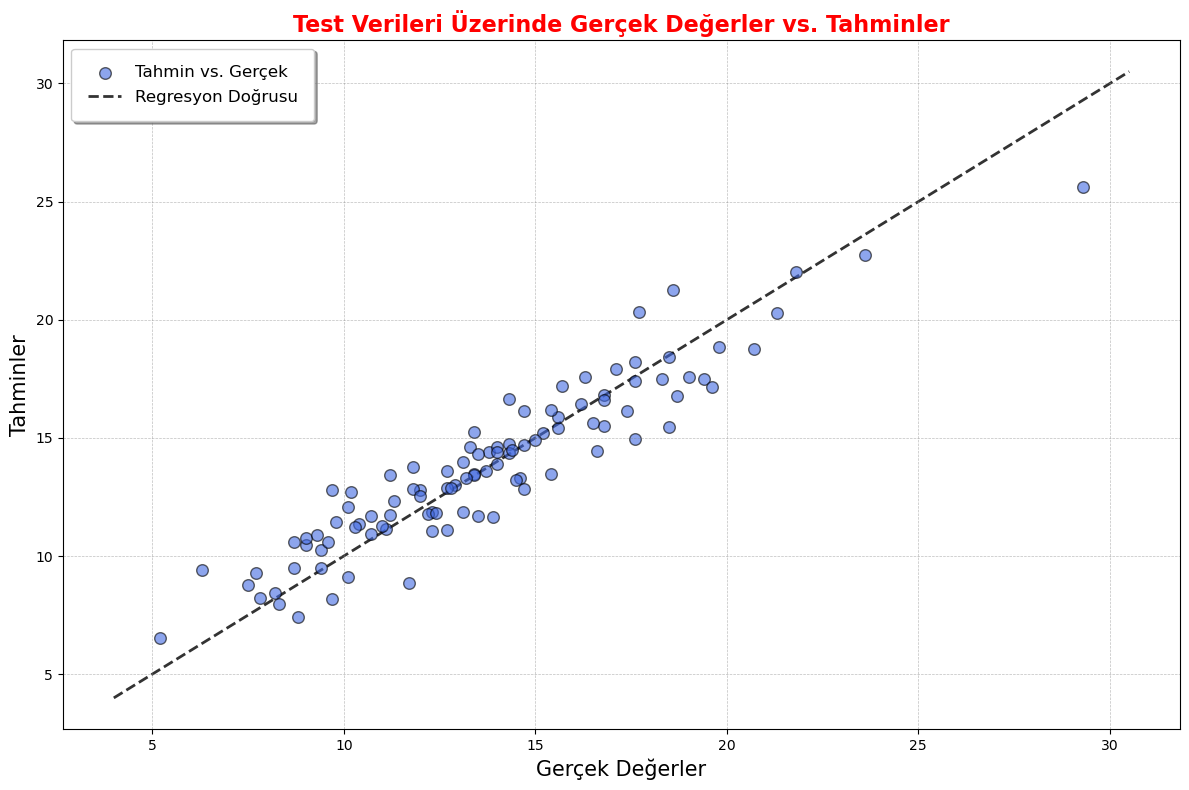

In [90]:
# Optimum Model 
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_optim_rf, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Gradient Boosting
--- 

In [91]:
# Gradient Boosting Machines default
gb_model0 = GradientBoostingRegressor().fit(X_train, y_train)
y_tahmin_gb_df = gb_model0.predict(X_test)
r2_skoru_default = r2_score(y_test, y_tahmin_gb_df)
mse_default  = mean_squared_error(y_test, y_tahmin_gb_df)

print(f"Default Gradient Boosting R^2 Skoru: {r2_skoru_default:.4f}")
print(f"Default Gradient Boosting MSE (Ortalama Kare Hata): {mse_default:.4f}")

Default Gradient Boosting R^2 Skoru: 0.8934
Default Gradient Boosting MSE (Ortalama Kare Hata): 1.6678


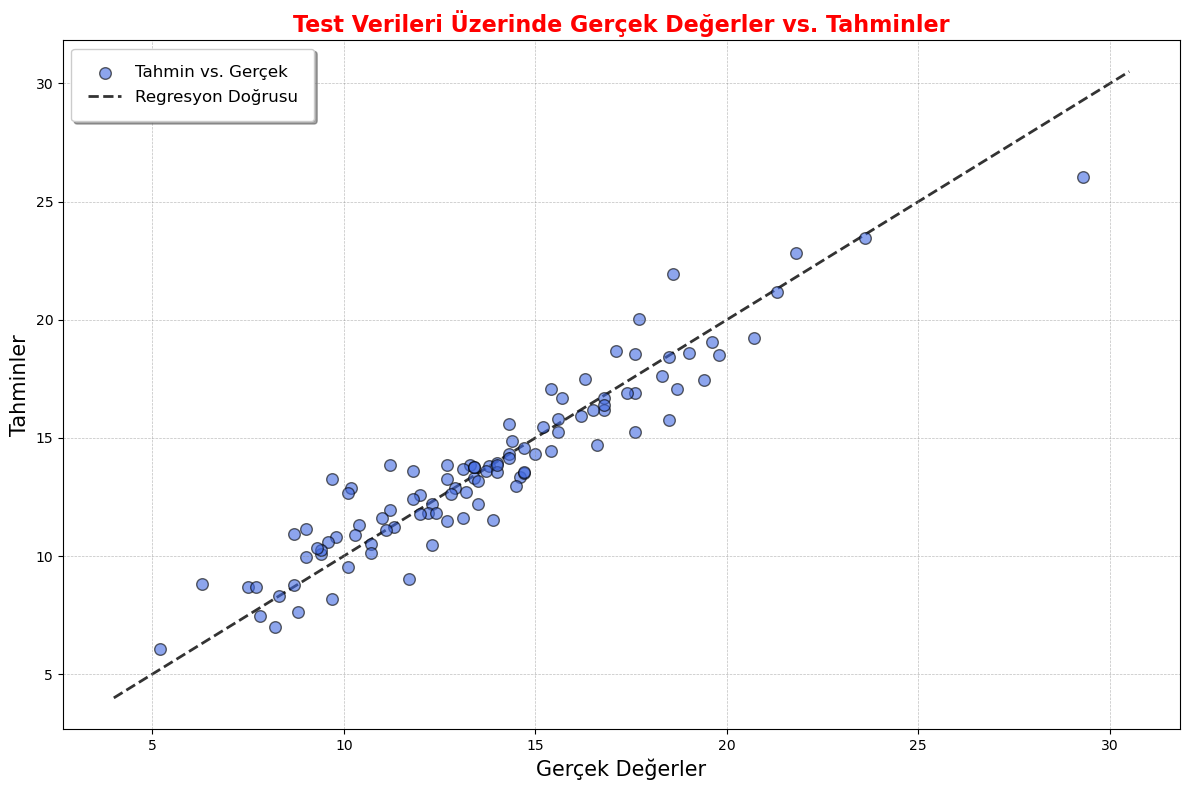

In [92]:
# Default Model Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_gb_df, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [93]:
# Model Optimizasyonu
gb_params = {
    "learning_rate": [0.001, 0.1, 0.2],
    "max_depth": [3, 5, 10],
    "n_estimators": [100, 500],
    "subsample": [0.5, 1]
}

In [94]:
GS_gb = GridSearchCV(gb_model0, gb_params, n_jobs=-1, cv=5).fit(X_train, y_train)
best_params = GS_gb.best_params_

print("Gradient Boosting Regressor için En İyi Parametreler:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Gradient Boosting Regressor için En İyi Parametreler:
learning_rate: 0.1
max_depth: 3
n_estimators: 100
subsample: 0.5


In [95]:
gb_best = GradientBoostingRegressor(learning_rate=0.1, max_depth=3, n_estimators=500,
                                   subsample=0.5).fit(X_train, y_train)

In [96]:
y_tahmin_best_gb = gb_best.predict(X_test)

r2_opt_gb = r2_score(y_test, y_tahmin_best_gb)
mse_opt_gb = mean_squared_error(y_test, y_tahmin_best_gb)

print(f"Optimum Gradient Boosting Modeli R^2 (R-squared) Değeri: {r2_opt_gb:.4f}")
print(f"Optimum Gradient Boosting Modeli MSE (Ortalama Karesel Hata): {mse_opt_gb:.4f}")

Optimum Gradient Boosting Modeli R^2 (R-squared) Değeri: 0.9285
Optimum Gradient Boosting Modeli MSE (Ortalama Karesel Hata): 1.1177


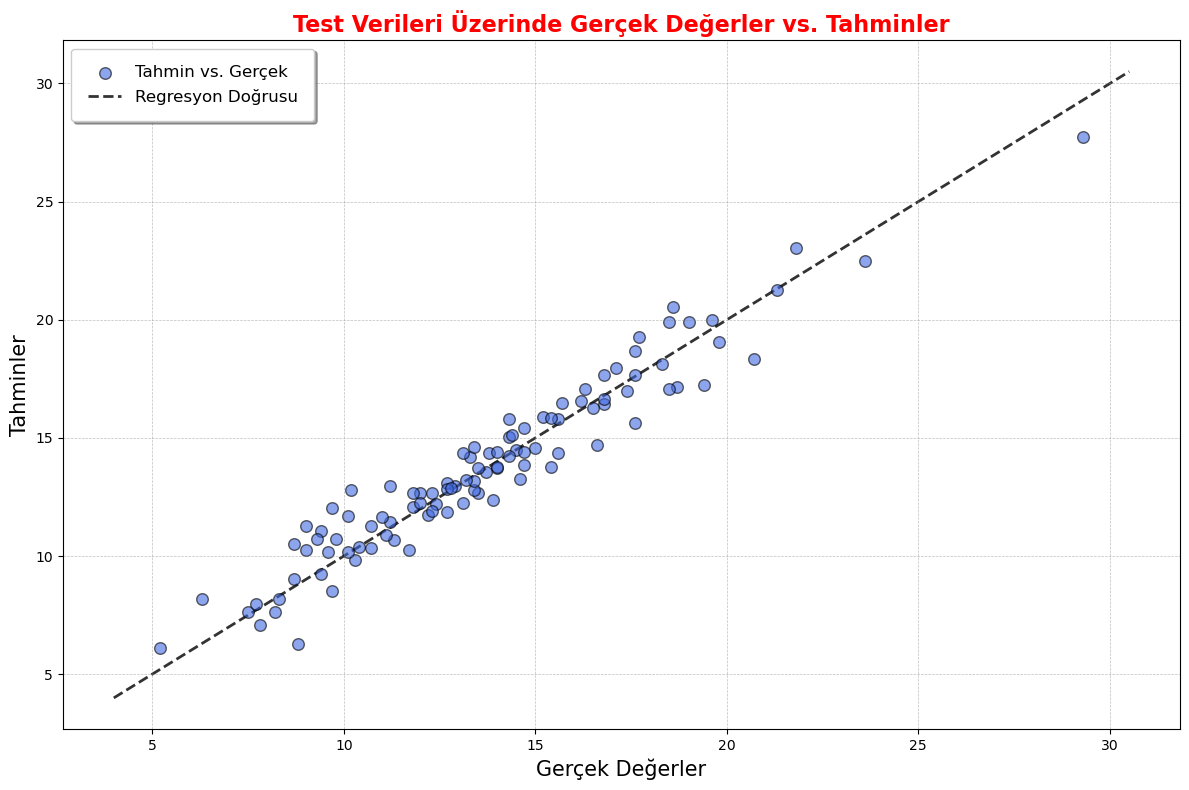

In [97]:
# Optimum Model Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_tahmin_best_gb, color="royalblue", alpha=0.6, edgecolor='black', s=70, label='Tahmin vs. Gerçek')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.8, zorder=0, linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Gerçek Değerler', fontsize=15)
plt.ylabel('Tahminler', fontsize=15)
plt.title('Test Verileri Üzerinde Gerçek Değerler vs. Tahminler', fontsize=16, fontweight='bold', color='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

---
### Karar Aşaması
---

In [98]:
scores = {
    "Lineer Regression": {"R^2 Score": r2_out_linear, "MSE": mse_out_linear},
    "PCA Linear Regression": {"R^2 Score": r2_out_pca, "MSE": mse_out_pca},
    "Optimum PLS Regression": {"R^2 Score": r2_score(y_test, y_tahmin_opt), "MSE": mean_squared_error(y_test, y_tahmin_opt)},
    "Optimum Ridge Regression": {"R^2 Score": r2_opt, "MSE": mse_opt},
    "Lasso Regression": {"R^2 Score": r2__opt, "MSE": mse__opt},
    "Optimum KNN": {"R^2 Score": r2_test_knnopt, "MSE": mse_test_knnopt},
    "Best Linear SVR": {"R^2 Score": r2_test, "MSE": mse_test},
    "Best Non-Linear SVR": {"R^2 Score": r2_test_nn, "MSE": mse_test_nn},
    "Best ANN Model": {"R^2 Score": best_r2, "MSE": best_mse},
    "Optimum Decision Tree": {"R^2 Score": r2_skoru_optimcart, "MSE": mse_degeri_optimcart},
    "Optimum Bagging Model": {"R^2 Score": r2_skoru_optimbag, "MSE": mse_degeri_optimbag},
    "Optimum Random Forest": {"R^2 Score": r2_opt_rf, "MSE": mse_opt_rf},
    "Optimum Gradient Boosting": {"R^2 Score": r2_opt_gb, "MSE": mse_opt_gb},
}

df_scores = pd.DataFrame(scores).T  
df_scores

,R^2 Score,MSE
Lineer Regression,0.972001,0.437859
PCA Linear Regression,0.001912,15.608559
Optimum PLS Regression,0.907059,1.453452
Optimum Ridge Regression,0.907059,1.453452
Lasso Regression,0.907059,1.453452
Optimum KNN,0.236545,11.939264
Best Linear SVR,0.954820,0.706544
Best Non-Linear SVR,0.240520,11.877092
Best ANN Model,0.943108,0.889709
Optimum Decision Tree,0.676201,5.063710


Genel olarak, düşük bir MSE (Mean Squared Error) ve yüksek bir R² skoru, modelimin iyi performans gösterdiğini gösterir. Ancak, çoklu bağlantı problemim olduğunda, regresyon tabanlı modellerimin performansı olumsuz etkilenebilir. Bu durumda, bağımsız değişkenlerin katsayı tahminleri yüksek varyans gösterebilir.

Grafiğime bakıldığında, hem en düşük MSE'ye hem de en yüksek R2 skoruna sahip modelimin 'Lineer Regression' olduğunu gözlemliyorum. Bu durum, veri setimin doğrusal modellerle çok daha başarılı bir şekilde modellenebildiğini gösteriyor.
  
Çoklu bağlantı sorunumu çözmek için Ridge ve Lasso regresyon gibi düzenlileştirme yöntemlerini kullandım. Bu yöntemlerle bazı değişkenlerin etkisini azaltmaya ve modelimin genel performansını iyileştirmeye çalıştım. Ancak, bu modellerin R² skorları nispeten düşük kaldı.

Sonuç olarak, veri setimdeki çoklu bağlantı sorununu hafifletmek ve model performansımı iyileştirmek için doğrusal olmayan modeller ve düzenlileştirme tekniklerinin etkili olduğunu gördüm. Lineer Regression modelimin yüksek R² skoru, veri setim için en uygun model olabileceğini işaret ediyor. Yine de, model seçimi ve değerlendirme yaparken, sadece bu iki metriğe göre karar vermek yerine, modelin kararlılığı, yorumlanabilirliği ve iş problemime uygunluğu gibi diğer faktörleri de dikkate alıyorum.
